# 0. Setup + intsalls

In [2]:
!pip -q install datasets pandas numpy matplotlib seaborn spacy gensim scikit-learn nltk scipy statsmodels requests
!python -m spacy download en_core_web_sm -q


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [3]:
import os, re, random, warnings, json, time
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.gridspec as gridspec
import seaborn as sns

import spacy
import nltk
from nltk.corpus import stopwords

from scipy.stats import kruskal, mannwhitneyu, chi2_contingency, spearmanr
import statsmodels.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

from datasets import load_dataset
from gensim import corpora
from gensim.models import LdaModel

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, cohen_kappa_score
from sklearn.pipeline import Pipeline

import requests

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

os.makedirs('outputs', exist_ok=True)

nlp = spacy.load('en_core_web_sm')

plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,})

sns.set_theme(style='whitegrid', palette='muted')
PALETTE = {'CNN': '#2E86AB', 'DailyMail': '#E84855'}

print('All imports successful. Outputs → ./outputs/')

All imports successful. Outputs → ./outputs/


# 1. Data loading + preprocessing

In [5]:
ds = load_dataset('abisee/cnn_dailymail', '1.0.0')
df_train = pd.DataFrame(ds['train'])
df_val = pd.DataFrame(ds['validation'])
df_test= pd.DataFrame(ds['test'])
print(f'Train={len(df_train):,}  Val={len(df_val):,}  Test={len(df_test):,}')

Train=287,113  Val=13,368  Test=11,490


In [6]:
def clean_text(text):
    """Strip invisible Unicode chars and normalise whitespace."""
    if not isinstance(text, str): return ''
    text = re.sub(r'[\u200b\u200c\u200d\ufeff\u00ad]', '', text)
    return re.sub(r'\s+', ' ', text).strip()

def infer_source(article):
    """CNN articles begin with '(CNN)', proxy outlet label."""
    if isinstance(article, str) and article.strip().startswith('(CNN)'): return 'CNN'
    return 'DailyMail'

for df in [df_train, df_val, df_test]:
    df['article_clean'] = df['article'].apply(clean_text)
    df['highlights_clean'] = df['highlights'].apply(clean_text)
    df['source'] = df['article_clean'].apply(infer_source)
    df['article_words'] = df['article_clean'].apply(lambda x: len(x.split()))
    df['highlight_words'] = df['highlights_clean'].apply(lambda x: len(x.split()))
    df['is_dup_article'] = df.duplicated(subset='article_clean', keep=False)

p1_art, p99_art = df_train['article_words'].quantile([0.01, 0.99])
p1_hl,  p99_hl  = df_train['highlight_words'].quantile([0.01, 0.99])
for df in [df_train, df_val, df_test]:
    df['article_outlier'] = (df['article_words'] < p1_art) | (df['article_words'] > p99_art)
    df['highlight_outlier'] = (df['highlight_words'] < p1_hl) | (df['highlight_words'] > p99_hl)

print('Missingness (train)')
for col in ['article', 'highlights', 'id']:
    print(f' {col}: nulls={df_train[col].isna().sum()}')
print(f'Source: CNN={df_train["source"].eq("CNN").mean():.1%}  DailyMail={df_train["source"].eq("DailyMail").mean():.1%}')
print(f'Duplicates: {df_train["is_dup_article"].sum():,} ({df_train["is_dup_article"].mean():.2%})')
print(f'Outlier thresholds: <{p1_art:.0f} or >{p99_art:.0f} words')

Missingness (train)
 article: nulls=0
 highlights: nulls=0
 id: nulls=0
Source: CNN=16.9%  DailyMail=83.1%
Duplicates: 6,210 (2.16%)
Outlier thresholds: <161 or >1674 words


# 2. Eda

In [8]:
rows = []
for name, df in [('Train', df_train), ('Validation', df_val), ('Test', df_test)]:
    rows.append({'Split': name, 'N': f'{len(df):,}',
                 'Art mean': f"{df['article_words'].mean():.0f}",
                 'Art median': f"{df['article_words'].median():.0f}",
                 'Hl mean': f"{df['highlight_words'].mean():.0f}",
                 'CNN %': f"{df['source'].eq('CNN').mean():.1%}",
                 'Dups %': f"{df['is_dup_article'].mean():.2%}"})
pd.DataFrame(rows).set_index('Split')

,N,Art mean,Art median,Hl mean,CNN %,Dups %
Split,,,,,,
Train,"287,113",692,632,52,16.9%,2.16%
Validation,"13,368",676,608,58,7.0%,0.00%
Test,"11,490",684,613,55,7.2%,0.03%


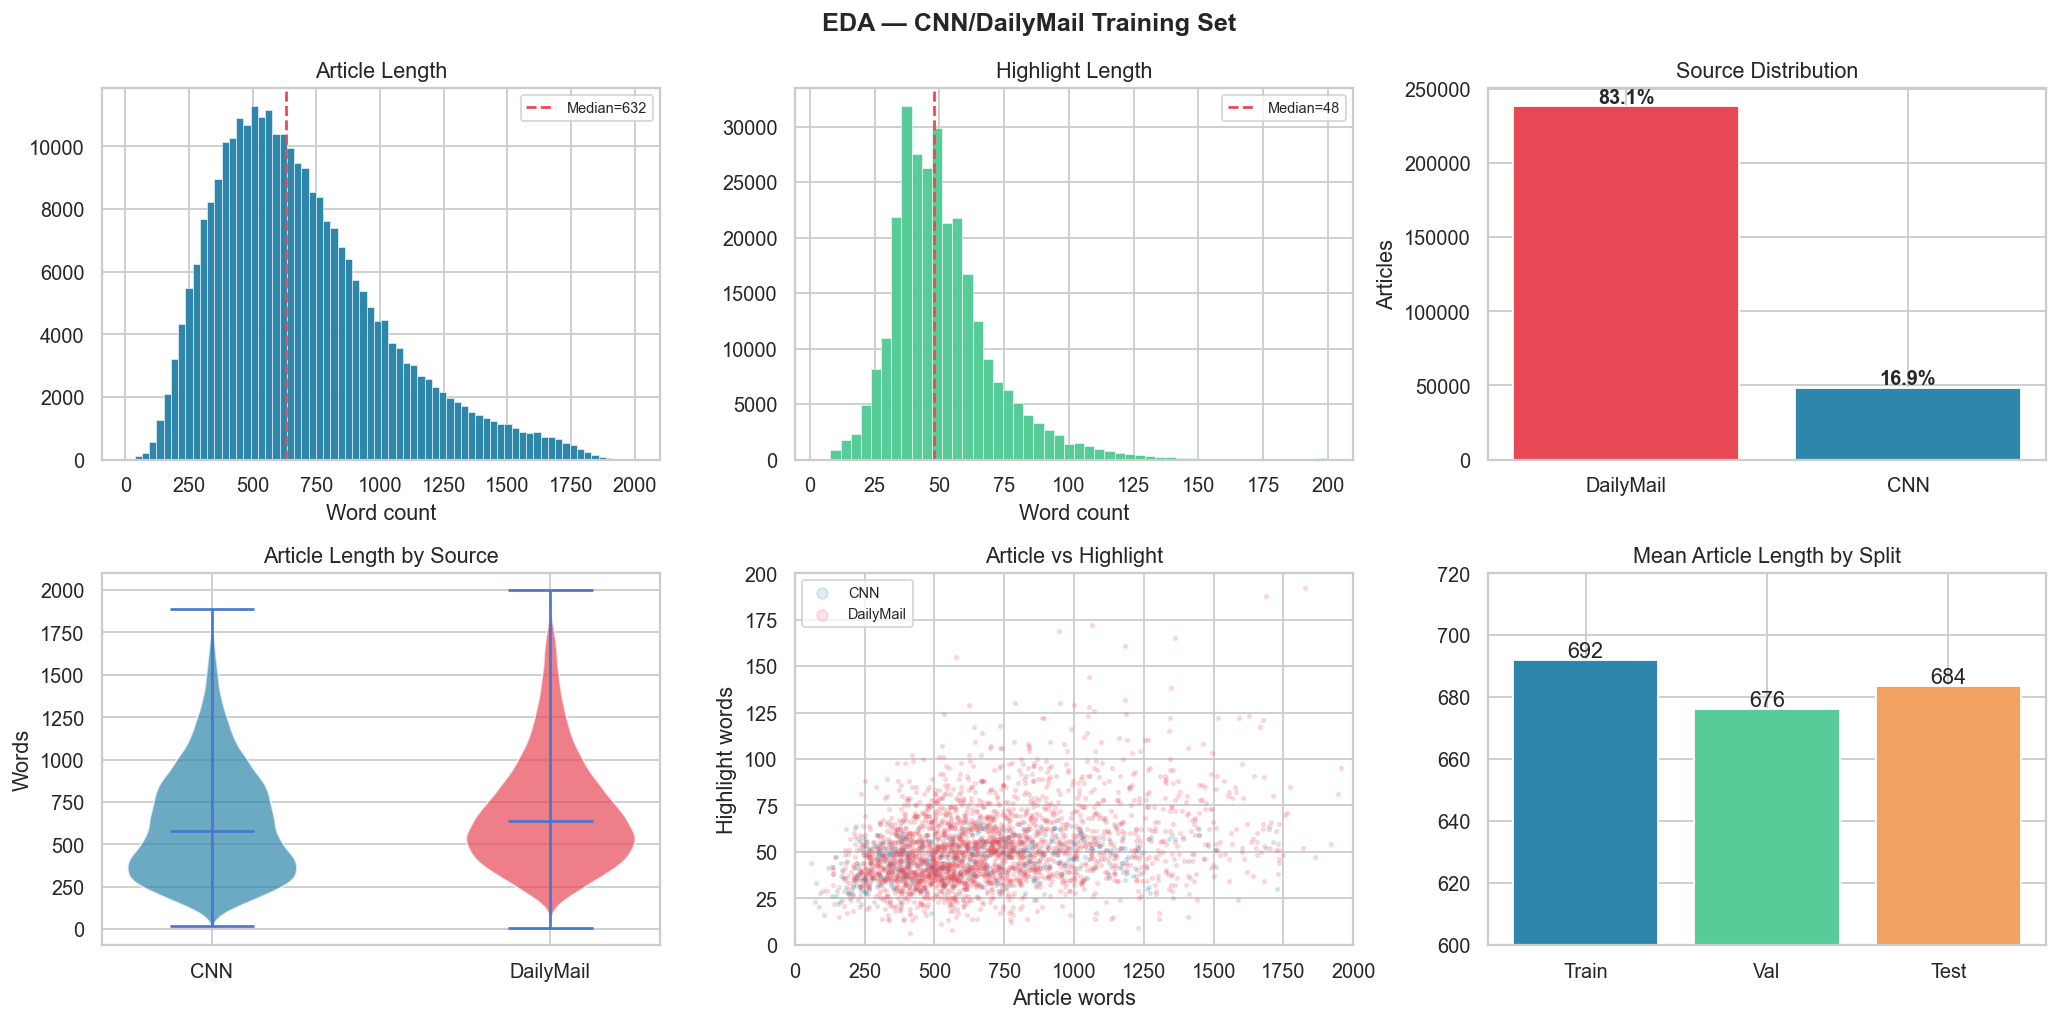

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('EDA — CNN/DailyMail Training Set', fontsize=14, fontweight='bold')

axes[0,0].hist(df_train['article_words'].clip(upper=2000), bins=70, color='#2E86AB', edgecolor='white', lw=0.3)
axes[0,0].axvline(df_train['article_words'].median(), color='#E84855', lw=1.5, ls='--',
                  label=f'Median={df_train["article_words"].median():.0f}')
axes[0,0].set_title('Article Length'); axes[0,0].set_xlabel('Word count'); axes[0,0].legend(fontsize=8)

axes[0,1].hist(df_train['highlight_words'].clip(upper=200), bins=50, color='#57CC99', edgecolor='white', lw=0.3)
axes[0,1].axvline(df_train['highlight_words'].median(), color='#E84855', lw=1.5, ls='--',
                  label=f'Median={df_train["highlight_words"].median():.0f}')
axes[0,1].set_title('Highlight Length'); axes[0,1].set_xlabel('Word count'); axes[0,1].legend(fontsize=8)

sc = df_train['source'].value_counts()
axes[0,2].bar(sc.index, sc.values, color=[PALETTE[s] for s in sc.index], edgecolor='white')
for i,(s,c) in enumerate(sc.items()): axes[0,2].text(i, c+2000, f'{c/len(df_train):.1%}', ha='center', fontsize=11, fontweight='bold')
axes[0,2].set_title('Source Distribution'); axes[0,2].set_ylabel('Articles')

dc = df_train[df_train['source']=='CNN']['article_words'].clip(upper=2000)
dd = df_train[df_train['source']=='DailyMail']['article_words'].clip(upper=2000)
vp = axes[1,0].violinplot([dc, dd], showmedians=True)
for i,pc in enumerate(vp['bodies']): pc.set_facecolor(list(PALETTE.values())[i]); pc.set_alpha(0.7)
axes[1,0].set_xticks([1,2]); axes[1,0].set_xticklabels(['CNN','DailyMail'])
axes[1,0].set_title('Article Length by Source'); axes[1,0].set_ylabel('Words')

sp = df_train.sample(3000, random_state=42)
for src, col in PALETTE.items():
    sub = sp[sp['source']==src]
    axes[1,1].scatter(sub['article_words'], sub['highlight_words'], alpha=0.15, s=4, color=col, label=src)
axes[1,1].set_title('Article vs Highlight'); axes[1,1].set_xlabel('Article words'); axes[1,1].set_ylabel('Highlight words')
axes[1,1].legend(fontsize=8, markerscale=3); axes[1,1].set_xlim(0,2000); axes[1,1].set_ylim(0,200)

split_means = {'Train': df_train['article_words'].mean(), 'Val': df_val['article_words'].mean(), 'Test': df_test['article_words'].mean()}
axes[1,2].bar(split_means.keys(), split_means.values(), color=['#2E86AB','#57CC99','#F4A261'], edgecolor='white')
axes[1,2].set_ylim(600,720); axes[1,2].set_title('Mean Article Length by Split')
for i,(k,v) in enumerate(split_means.items()): axes[1,2].text(i, v+1, f'{v:.0f}', ha='center')

plt.tight_layout()
plt.savefig('outputs/fig_01_eda.png', dpi=150, bbox_inches='tight')
plt.show()

# 3. Direct quote extraction

In [11]:
QUOTE_PAT = re.compile(r'["\u201c\u2018]([^"\u201d\u2019]{10,500}?)["\u201d\u2019]')

def extract_direct_quotes(text):
    if not isinstance(text, str) or not text: return []
    total_len = max(len(text), 1)
    return [{'text': m.group(1).strip(), 'start': m.start(), 'end': m.end(),
             'rel_pos': round(m.start()/total_len, 4),
             'length_words': len(m.group(1).split()),
             'length_chars': len(m.group(1))}
            for m in QUOTE_PAT.finditer(text) if m.group(1).strip()]

df_train['direct_quotes'] = df_train['article_clean'].apply(extract_direct_quotes)
df_train['n_direct_quotes'] = df_train['direct_quotes'].apply(len)
df_train['has_direct_quote'] = df_train['n_direct_quotes'] > 0
df_train['first_quote_relpos'] = df_train['direct_quotes'].apply(lambda qs: qs[0]['rel_pos'] if qs else np.nan)
df_train['mean_quote_length'] = df_train['direct_quotes'].apply(lambda qs: np.mean([q['length_words'] for q in qs]) if qs else np.nan)
df_train['total_quoted_words'] = df_train['direct_quotes'].apply(lambda qs: sum(q['length_words'] for q in qs))
df_train['quote_density'] = df_train['total_quoted_words'] / df_train['article_words'].replace(0,np.nan) * 1000

print('Direct Quote Statistics')
print(f'With >=1 direct quote: {df_train["has_direct_quote"].mean():.1%}  (n={df_train["has_direct_quote"].sum():,})')
print(f'Mean quotes/article:{df_train["n_direct_quotes"].mean():.2f}')
print(f'Mean quote density: {df_train["quote_density"].mean():.1f} per 1k words')
print()
print(df_train.groupby('source')[['has_direct_quote','n_direct_quotes','first_quote_relpos','quote_density']].agg(['mean','median']).round(3))

Direct Quote Statistics
With >=1 direct quote: 56.4%  (n=161,887)
Mean quotes/article:3.96
Mean quote density: 95.9 per 1k words

          has_direct_quote        n_direct_quotes        first_quote_relpos  \
                      mean median            mean median               mean   
source                                                                        
CNN                  0.913    1.0           7.838    6.0              0.207   
DailyMail            0.493    0.0           3.167    0.0              0.303   

                 quote_density           
          median          mean   median  
source                                   
CNN        0.148       202.866  188.729  
DailyMail  0.234        74.092    0.000  


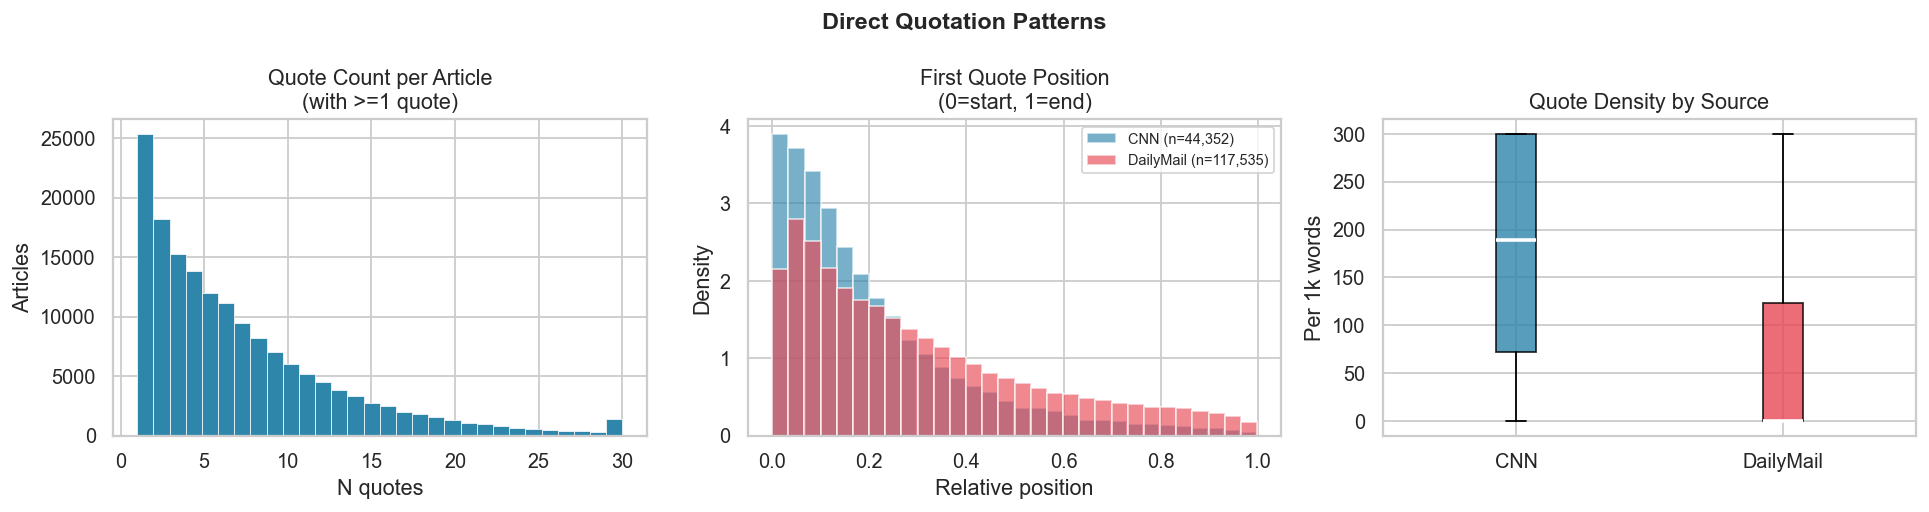

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Direct Quotation Patterns', fontsize=13, fontweight='bold')

df_train[df_train['n_direct_quotes']>0]['n_direct_quotes'].clip(upper=30).hist(
    bins=30, ax=axes[0], color='#2E86AB', edgecolor='white', lw=0.4)
axes[0].set_title('Quote Count per Article\n(with >=1 quote)'); axes[0].set_xlabel('N quotes'); axes[0].set_ylabel('Articles')

for src, col in PALETTE.items():
    d = df_train[(df_train['source']==src) & df_train['first_quote_relpos'].notna()]['first_quote_relpos']
    axes[1].hist(d, bins=30, alpha=0.65, color=col, label=f'{src} (n={len(d):,})', density=True)
axes[1].set_title('First Quote Position\n(0=start, 1=end)'); axes[1].set_xlabel('Relative position')
axes[1].set_ylabel('Density'); axes[1].legend(fontsize=8)

dc2 = df_train[df_train['source']=='CNN']['quote_density'].clip(upper=300).dropna()
dd2 = df_train[df_train['source']=='DailyMail']['quote_density'].clip(upper=300).dropna()
bp = axes[2].boxplot([dc2, dd2], patch_artist=True, medianprops=dict(color='white', lw=2))
for patch, color in zip(bp['boxes'], PALETTE.values()): patch.set_facecolor(color); patch.set_alpha(0.8)
axes[2].set_xticklabels(['CNN','DailyMail']); axes[2].set_title('Quote Density by Source'); axes[2].set_ylabel('Per 1k words')

plt.tight_layout()
plt.savefig('outputs/fig_02_quotes.png', dpi=150, bbox_inches='tight')
plt.show()

# 4. Indirect quote detection

In [14]:
REPORTING_VERBS = [
    'said','told','claimed','announced','warned','admitted','insisted','confirmed',
    'suggested','alleged','noted','stated','argued','added','explained','revealed',
    'indicated','reported','denied','stressed','emphasized','emphasised','predicted',
    'acknowledged','declared','urged','cautioned','believed','found','showed',
    'demonstrated','maintained','contended','described','mentioned','questioned',
    'disputed','implied','hinted','speculated',]

RV_SET = set(REPORTING_VERBS)

_rv_alt = '|'.join(re.escape(v) for v in REPORTING_VERBS)
INDIRECT_REGEX = re.compile(rf'\b({_rv_alt})\s+that\b', re.IGNORECASE)

df_train['n_indirect_regex'] = df_train['article_clean'].apply(
    lambda t: len(INDIRECT_REGEX.findall(t)) if isinstance(t, str) else 0)

print(f'Method A (Regex): {(df_train["n_indirect_regex"]>0).mean():.1%} articles with >=1 indirect quote pattern')
print(df_train['n_indirect_regex'].describe().round(3))

Method A (Regex): 37.4% articles with >=1 indirect quote pattern
count    287113.000
mean          0.672
std           1.162
min           0.000
25%           0.000
50%           0.000
75%           1.000
max          22.000
Name: n_indirect_regex, dtype: float64


In [15]:
# Method B: spaCy (small sample)
SPACY_IQ_SAMPLE = 200
iq_idx = df_train.sample(SPACY_IQ_SAMPLE, random_state=42).index

def detect_indirect_spacy(text):
    if not isinstance(text, str): return 0
    doc = nlp(text[:3000])
    return sum(1 for tok in doc if tok.dep_ in ('ccomp','xcomp') and tok.head.lemma_.lower() in RV_SET)

df_train.loc[iq_idx, 'n_indirect_spacy'] = df_train.loc[iq_idx, 'article_clean'].apply(detect_indirect_spacy)

iq_sample = df_train.loc[iq_idx, ['n_indirect_regex','n_indirect_spacy']].dropna()
print(f'Method B (spaCy): {(iq_sample["n_indirect_spacy"]>0).mean():.1%} articles with detections (n={SPACY_IQ_SAMPLE})')
print()
if iq_sample['n_indirect_spacy'].sum() == 0:
    print('⚠spaCy detected ZERO indirect clauses.')
    print(' Cause: en_core_web_sm has limited syntactic depth on short news text.')
    print(' en_core_web_lg would likely improve this but requires more MB download.')
    print(' → DECISION: Regex proxy selected for all downstream analysis.')

Method B (spaCy): 0.0% articles with detections (n=200)

⚠spaCy detected ZERO indirect clauses.
 Cause: en_core_web_sm has limited syntactic depth on short news text.
 en_core_web_lg would likely improve this but requires more MB download.
 → DECISION: Regex proxy selected for all downstream analysis.


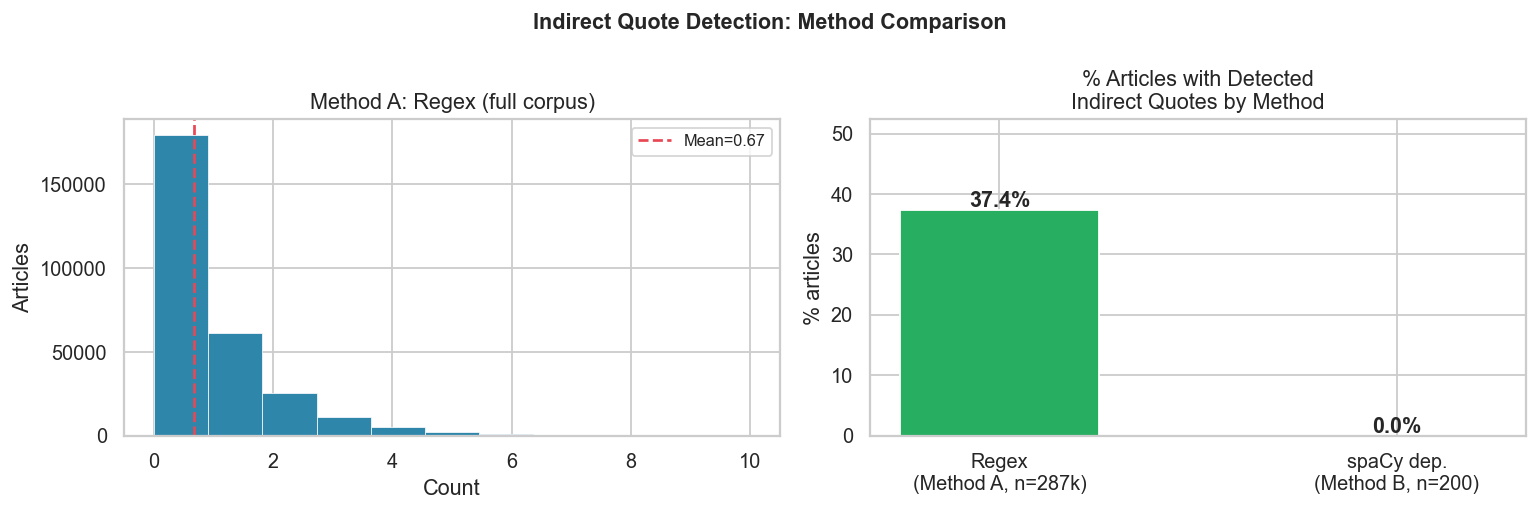

→ Regex (Method A) selected for all downstream analysis.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Indirect Quote Detection: Method Comparison', fontsize=12, fontweight='bold')

axes[0].hist(df_train['n_indirect_regex'].clip(upper=10), bins=11, color='#2E86AB', edgecolor='white', lw=0.4)
axes[0].axvline(df_train['n_indirect_regex'].mean(), color='#E84855', lw=1.5, ls='--',
                label=f'Mean={df_train["n_indirect_regex"].mean():.2f}')
axes[0].set_title('Method A: Regex (full corpus)'); axes[0].set_xlabel('Count'); axes[0].set_ylabel('Articles'); axes[0].legend(fontsize=9)

methods = ['Regex\n(Method A, n=287k)', 'spaCy dep.\n(Method B, n=200)']
coverage = [(df_train['n_indirect_regex']>0).mean()*100, (iq_sample['n_indirect_spacy']>0).mean()*100]
bars = axes[1].bar(methods, coverage, color=['#27AE60','#E84855'], edgecolor='white', width=0.5)
for bar, val in zip(bars, coverage):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+0.5, f'{val:.1f}%', ha='center', fontweight='bold')
axes[1].set_title('% Articles with Detected\nIndirect Quotes by Method'); axes[1].set_ylabel('% articles')
axes[1].set_ylim(0, max(coverage)*1.4)

plt.tight_layout()
plt.savefig('outputs/fig_03_indirect_methods.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ Regex (Method A) selected for all downstream analysis.')

# 5. Reporting verb analysis + authority taxononmy


In [18]:
VERB_SCORES = {
    'confirmed':3,'announced':3,'warned':3,'declared':3,'revealed':3,
    'emphasized':3,'emphasised':3,'demonstrated':3,'showed':3,'proved':3,
    'established':3,'urged':3,'demanded':3,'insisted':3,
    'said':2,'told':2,'noted':2,'added':2,'explained':2,'reported':2,
    'indicated':2,'stated':2,'described':2,'mentioned':2,'acknowledged':2,
    'claimed':1,'alleged':1,'suggested':1,'appeared':1,'seemed':1,
    'believed':1,'argued':1,'contended':1,'maintained':1,'implied':1,
    'hinted':1,'speculated':1,'questioned':1,'denied':1,'disputed':1,}

VERB_CAT = {v:('strong' if s==3 else 'neutral' if s==2 else 'weak') for v,s in VERB_SCORES.items()}
HIGH_CERT = {'will','must','clearly','definitely','certainly','undoubtedly','proven','absolutely','conclusively'}
LOW_CERT  = {'may','might','could','perhaps','possibly','allegedly','reportedly',
             'apparently','seemingly','supposedly','purportedly','probably'}
VERB_REGEX = re.compile(r'\b(' + '|'.join(re.escape(v) for v in VERB_SCORES) + r')\b', re.IGNORECASE)

def extract_verb_features(text):
    if not isinstance(text, str): return {}
    words = text.lower().split()
    vc = Counter(m.group(1).lower() for m in VERB_REGEX.finditer(text))
    strong  = sum(vc[v] for v in vc if VERB_CAT.get(v)=='strong')
    neutral = sum(vc[v] for v in vc if VERB_CAT.get(v)=='neutral')
    weak    = sum(vc[v] for v in vc if VERB_CAT.get(v)=='weak')
    total   = strong + neutral + weak
    hc = sum(1 for w in words if w.rstrip('.,') in HIGH_CERT)
    lc = sum(1 for w in words if w.rstrip('.,') in LOW_CERT)
    cd = hc + lc
    return {'rv_strong':strong,'rv_neutral':neutral,'rv_weak':weak,'rv_total':total,
            'rv_authority_score':(3*strong+2*neutral+weak)/total if total>0 else np.nan,
            'rv_pct_strong':strong/total if total>0 else np.nan,
            'rv_pct_weak':weak/total if total>0 else np.nan,
            'high_certainty':hc,'low_certainty':lc,
            'certainty_ratio':hc/cd if cd>0 else np.nan,
            'dominant_rv':vc.most_common(1)[0][0] if vc else None}

verb_df = pd.DataFrame(df_train['article_clean'].apply(extract_verb_features).tolist())
df_train = pd.concat([df_train.reset_index(drop=True), verb_df.reset_index(drop=True)], axis=1)

print('Reporting Verb Summary')
print(df_train[['rv_strong','rv_neutral','rv_weak','rv_authority_score','certainty_ratio']].describe().round(3))

all_verbs = [m.group(1).lower() for text in df_train['article_clean'].dropna() for m in VERB_REGEX.finditer(text)]
verb_freq_all = Counter(all_verbs)
print(f'\nMost frequent verb: {verb_freq_all.most_common(1)[0][0]} ({verb_freq_all.most_common(1)[0][1]:,} occurrences)')

Reporting Verb Summary
        rv_strong  rv_neutral     rv_weak  rv_authority_score  certainty_ratio
count  287113.000  287113.000  287113.000          270469.000       254201.000
mean        0.824       6.466       0.845               2.014            0.491
std         1.212       5.986       1.411               0.280            0.361
min         0.000       0.000       0.000               1.000            0.000
25%         0.000       2.000       0.000               1.917            0.167
50%         0.000       5.000       0.000               2.000            0.500
75%         1.000       9.000       1.000               2.111            0.800
max        21.000      61.000      26.000               3.000            1.000

Most frequent verb: said (1,307,477 occurrences)


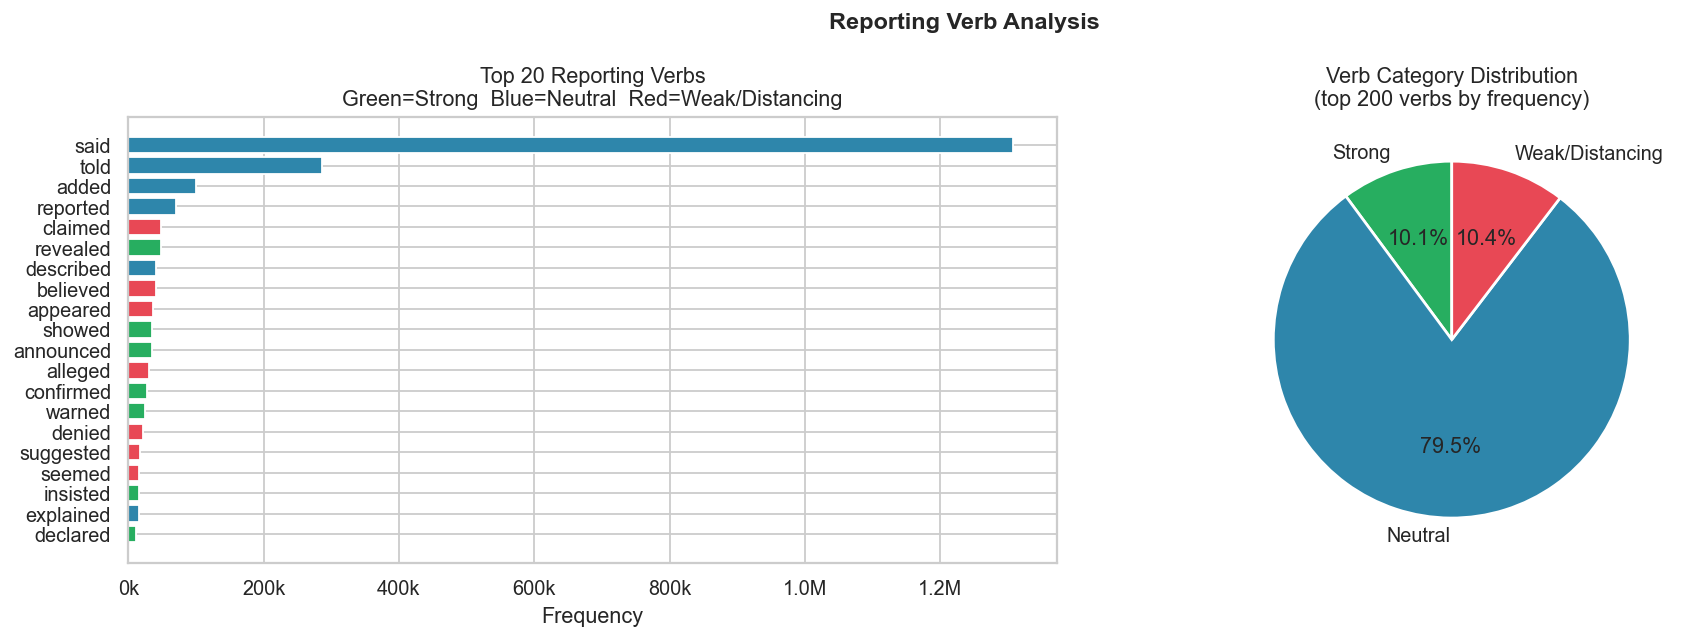

In [19]:
top20 = verb_freq_all.most_common(20)
v_labels, v_counts = zip(*top20)
v_colors = ['#27AE60' if VERB_CAT.get(v)=='strong' else '#2E86AB' if VERB_CAT.get(v)=='neutral' else '#E84855' for v in v_labels]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Reporting Verb Analysis', fontsize=13, fontweight='bold')

axes[0].barh(list(v_labels)[::-1], list(v_counts)[::-1], color=list(v_colors)[::-1])
axes[0].set_xlabel('Frequency')
axes[0].set_title('Top 20 Reporting Verbs\nGreen=Strong  Blue=Neutral  Red=Weak/Distancing')
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,p: f'{x/1e6:.1f}M' if x>=1e6 else f'{int(x/1e3)}k'))

# Verb category pie
cats = {'strong': sum(v for vl,v in verb_freq_all.most_common(200) if VERB_CAT.get(vl)=='strong'),
        'neutral': sum(v for vl,v in verb_freq_all.most_common(200) if VERB_CAT.get(vl)=='neutral'),
        'weak': sum(v for vl,v in verb_freq_all.most_common(200) if VERB_CAT.get(vl)=='weak')}
axes[1].pie(list(cats.values()), labels=['Strong','Neutral','Weak/Distancing'],
            colors=['#27AE60','#2E86AB','#E84855'], autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', lw=1.5))
axes[1].set_title('Verb Category Distribution\n(top 200 verbs by frequency)')

plt.tight_layout()
plt.savefig('outputs/fig_04_reporting_verbs.png', dpi=150, bbox_inches='tight')
plt.show()

# 6. NER + speaker attribution

In [ ]:
INSTITUTIONAL_MARKERS = [
    'government','minister','president','secretary','director','chief','official',
    'spokesman','spokesperson','representative','senator','congressman','mp','ceo',
    'chairman','professor','doctor','dr','general','commander','commissioner',
    'judge','attorney','prosecutor','investigator','analyst','expert','researcher',
    'scientist','adviser','advisor','officer','lieutenant','captain','colonel','ambassador',]

INSTITUTION_REGEX = re.compile(r'\b(' + '|'.join(re.escape(m) for m in INSTITUTIONAL_MARKERS) + r')\b', re.IGNORECASE)
ANON_REGEX = re.compile(
    r'\b(a source|an official|an aide|a spokesperson|a spokesman|sources said|'
    r'officials said|sources familiar|people familiar|according to sources|unnamed official)\b', re.IGNORECASE)

def extract_ner_features(text):
    empty = {'persons':[],'n_person_entities':0,'n_unique_persons':0,'n_orgs':0,
             'institutional_count':0,'anon_source_count':0,'attribution_type':'none'}
    if not isinstance(text, str): return empty
    doc = nlp(text[:6000])
    persons = [ent.text.strip() for ent in doc.ents if ent.label_=='PERSON']
    orgs = [ent.text.strip() for ent in doc.ents if ent.label_=='ORG']
    inst = len(INSTITUTION_REGEX.findall(text))
    anon = len(ANON_REGEX.findall(text))
    if inst > anon and inst > 0: attr = 'institutional'
    elif anon > 0 and anon >= inst: attr = 'anonymous'
    elif persons: attr = 'individual'
    else: attr = 'none'
    return {'persons':persons,'n_person_entities':len(persons),'n_unique_persons':len(set(persons)),
            'n_orgs':len(orgs),'institutional_count':inst,'anon_source_count':anon,'attribution_type':attr}

# Use nlp.pipe for speed (3-5x faster than .apply)
NER_SAMPLE = 20000
ner_idx = df_train.sample(NER_SAMPLE, random_state=42).index
print(f'Running NER on {NER_SAMPLE:,} articles using batch processing...')
texts_ner = df_train.loc[ner_idx, 'article_clean'].fillna('').tolist()
ner_results_list = []
for doc in nlp.pipe([t[:6000] for t in texts_ner], batch_size=64, n_process=1):
    persons = [ent.text.strip() for ent in doc.ents if ent.label_=='PERSON']
    orgs = [ent.text.strip() for ent in doc.ents if ent.label_=='ORG']
    inst = len(INSTITUTION_REGEX.findall(doc.text))
    anon = len(ANON_REGEX.findall(doc.text))
    if inst > anon and inst > 0: attr = 'institutional'
    elif anon > 0 and anon >= inst: attr = 'anonymous'
    elif persons: attr = 'individual'
    else: attr = 'none'
    ner_results_list.append({'persons':persons,'n_person_entities':len(persons),
        'n_unique_persons':len(set(persons)),'n_orgs':len(orgs),
        'institutional_count':inst,'anon_source_count':anon,'attribution_type':attr})

ner_df = pd.DataFrame(ner_results_list, index=ner_idx)
for col in ner_df.columns:
    df_train.loc[ner_idx, col] = ner_df[col]

print('\n NER Results')
print(df_train.loc[ner_idx,['n_person_entities','n_unique_persons','n_orgs']].describe().round(2))
print('\nAttribution type:')
print(df_train.loc[ner_idx,'attribution_type'].value_counts(normalize=True).round(3))

In [22]:
def link_speakers_to_quotes(text, quotes, window=350):
    """Proximity heuristic: nearest PERSON entity within +/- window chars."""
    if not text or not quotes: return []
    doc = nlp(text[:6000])
    positions = [(ent.text.strip(), ent.start_char) for ent in doc.ents if ent.label_=='PERSON']
    linked = []
    for q in quotes:
        best_speaker, best_dist = None, float('inf')
        for name, pos in positions:
            dist = abs(pos - q['start'])
            if dist < best_dist and dist <= window:
                best_dist, best_speaker = dist, name
        linked.append({'quote':q['text'][:120],'speaker':best_speaker,
                       'dist':best_dist if best_speaker else None,
                       'attributed':best_speaker is not None,
                       'rel_pos':q['rel_pos'],'length_words':q['length_words']})
    return linked

LINK_SAMPLE = 500
link_idx = df_train[df_train['has_direct_quote']].sample(LINK_SAMPLE, random_state=42).index
link_results = pd.Series(
    [link_speakers_to_quotes(row.article_clean, row.direct_quotes)
     for row in df_train.loc[link_idx].itertuples()],
    index=link_idx, dtype=object)
if 'speaker_quote_links' not in df_train.columns:
    df_train['speaker_quote_links'] = pd.Series(dtype=object)
df_train.loc[link_idx, 'speaker_quote_links'] = link_results

all_links = [l for links in df_train.loc[link_idx,'speaker_quote_links'].dropna() for l in links]
n_total = len(all_links)
n_attr  = sum(1 for l in all_links if l['attributed'])
print(f'Speaker attribution rate: {n_attr:,}/{n_total:,} = {n_attr/n_total:.1%}')

Speaker attribution rate: 3,133/3,711 = 84.4%


# 7. Gender inference


In [ ]:
GENDER_DICT = {
    'mary':'female','patricia':'female','jennifer':'female','linda':'female',
    'barbara':'female','elizabeth':'female','susan':'female','jessica':'female',
    'sarah':'female','karen':'female','lisa':'female','nancy':'female','betty':'female',
    'margaret':'female','sandra':'female','ashley':'female','dorothy':'female',
    'kimberly':'female','emily':'female','donna':'female','michelle':'female',
    'carol':'female','amanda':'female','melissa':'female','deborah':'female',
    'stephanie':'female','rebecca':'female','sharon':'female','laura':'female',
    'cynthia':'female','kathleen':'female','amy':'female','angela':'female',
    'shirley':'female','anna':'female','brenda':'female','pamela':'female',
    'emma':'female','nicole':'female','helen':'female','samantha':'female',
    'katherine':'female','christine':'female','rachel':'female','carolyn':'female',
    'janet':'female','catherine':'female','maria':'female','heather':'female',
    'diane':'female','julie':'female','victoria':'female','kelly':'female',
    'christina':'female','joan':'female','evelyn':'female','lauren':'female',
    'judith':'female','olivia':'female','frances':'female','martha':'female',
    'cheryl':'female','megan':'female','andrea':'female','hannah':'female',
    'jacqueline':'female','ann':'female','gloria':'female','jean':'female',
    'kathryn':'female','alice':'female','teresa':'female','sara':'female',
    'janice':'female','marie':'female','julia':'female','grace':'female',
    'judy':'female','theresa':'female','beverly':'female','denise':'female',
    'marilyn':'female','amber':'female','danielle':'female','abigail':'female',
    'brittany':'female','rose':'female','diana':'female','natalie':'female',
    'sophia':'female','alexis':'female','lori':'female','kayla':'female',
    'jane':'female','hillary':'female','jacinda':'female','nikki':'female',
    'kamala':'female','oprah':'female','condoleezza':'female','sonia':'female',
    'elena':'female','ruth':'female','priyanka':'female','malala':'female',
    'nicola':'female','yvette':'female','harriet':'female','marylisa':'female',
    'tuff':'female','ms':'female',
    'james':'male','john':'male','robert':'male','michael':'male','william':'male',
    'david':'male','richard':'male','joseph':'male','thomas':'male','charles':'male',
    'christopher':'male','daniel':'male','matthew':'male','anthony':'male',
    'mark':'male','donald':'male','steven':'male','paul':'male','andrew':'male',
    'joshua':'male','kenneth':'male','kevin':'male','brian':'male','george':'male',
    'timothy':'male','ronald':'male','edward':'male','jason':'male','jeffrey':'male',
    'ryan':'male','jacob':'male','gary':'male','nicholas':'male','eric':'male',
    'jonathan':'male','stephen':'male','larry':'male','justin':'male','scott':'male',
    'brandon':'male','benjamin':'male','samuel':'male','raymond':'male','gregory':'male',
    'frank':'male','alexander':'male','patrick':'male','jack':'male','dennis':'male',
    'jerry':'male','tyler':'male','aaron':'male','jose':'male','adam':'male',
    'henry':'male','nathan':'male','douglas':'male','zachary':'male','peter':'male',
    'kyle':'male','walter':'male','ethan':'male','jeremy':'male','harold':'male',
    'keith':'male','christian':'male','roger':'male','noah':'male','joe':'male',
    'alan':'male','juan':'male','louis':'male','wayne':'male','bruce':'male',
    'dylan':'male','arthur':'male','sean':'male','carlos':'male','ralph':'male',
    'shawn':'male','austin':'male','roy':'male','liam':'male','barack':'male',
    'trump':'male','biden':'male','obama':'male','boris':'male','vladimir':'male',
    'emmanuel':'male','xi':'male','modi':'male','putin':'male','macron':'male',
    'erdogan':'male','nigel':'male','rishi':'male','mitt':'male','medvedev':'male',
    'romney':'male','clinton':'male','johnson':'male','jackson':'male','brown':'male',
    'taylor':'male','miller':'male','jamie':'male','lee':'male','schmidt':'male',
    'cranston':'male','erickson':'male','jacobs':'male','herren':'male',}

# Genderize.io API for names not in dictionary
GENDERIZE_CACHE_FILE = 'outputs/genderize_cache.json'

def load_genderize_cache():
    if os.path.exists(GENDERIZE_CACHE_FILE):
        with open(GENDERIZE_CACHE_FILE) as f:
            return json.load(f)
    return {}

def save_genderize_cache(cache):
    with open(GENDERIZE_CACHE_FILE, 'w') as f:
        json.dump(cache, f, indent=2)

def genderize_lookup(first_name, cache):
    """Query Genderize.io API with caching. Returns (gender, probability)."""
    key = first_name.lower().strip()
    if key in cache:
        return cache[key].get('gender','unknown'), cache[key].get('probability', 0)
    try:
        r = requests.get(f'https://api.genderize.io/?name={key}', timeout=5)
        if r.status_code == 200:
            data = r.json()
            gender = data.get('gender') or 'unknown'
            prob   = data.get('probability') or 0
            cache[key] = {'gender': gender, 'probability': prob}
            save_genderize_cache(cache)
            time.sleep(0.3)  # polite rate limiting
            return gender, prob
    except Exception:
        pass
    return 'unknown', 0

def infer_gender(name, genderize_cache=None, use_api=False):
    """
    Stage 1: dictionary lookup.
    Stage 2: Genderize.io API (if use_api=True and name not in dict).
    Returns (gender, source, probability).
    """
    if not isinstance(name, str) or not name.strip():
        return 'unknown', 'none', 0
    first = name.strip().split()[0].lower().rstrip('.,!?')
    if first in GENDER_DICT:
        return GENDER_DICT[first], 'dictionary', 1.0
    if use_api and genderize_cache is not None:
        g, prob = genderize_lookup(first, genderize_cache)
        if g != 'unknown' and prob >= 0.7:  # only accept high confidence API results
            return g, 'genderize', prob
    return 'unknown', 'none', 0

def article_gender_stats(persons, genderize_cache=None, use_api=False):
    if not isinstance(persons, list) or not persons:
        return {'n_male':0,'n_female':0,'n_unknown':0,'pct_male':np.nan,'pct_female':np.nan,'pct_unknown':np.nan}
    genders = [infer_gender(p, genderize_cache, use_api)[0] for p in persons]
    n = max(len(genders), 1)
    nm, nf, nu = genders.count('male'), genders.count('female'), genders.count('unknown')
    return {'n_male':nm,'n_female':nf,'n_unknown':nu,'pct_male':nm/n,'pct_female':nf/n,'pct_unknown':nu/n}

genderize_cache = load_genderize_cache()

# Run gender inference on NER sample
# Set use_api=True to call Genderize.io for names not in the dictionary
# Set use_api=False for offline
USE_GENDERIZE_API = True  # set True on first run to populate cache, False thereafter

gender_df = pd.DataFrame(
    df_train.loc[ner_idx,'persons'].apply(
        lambda p: article_gender_stats(p if isinstance(p,list) else [], genderize_cache, USE_GENDERIZE_API)
    ).tolist(), index=ner_idx)
for col in gender_df.columns:
    df_train.loc[ner_idx, col] = gender_df[col]

tp = df_train.loc[ner_idx,['n_male','n_female','n_unknown']].sum()
cr = (tp['n_male']+tp['n_female'])/tp.sum()
print('Gender Inference')
print(df_train.loc[ner_idx,['pct_male','pct_female','pct_unknown']].describe().round(3))
print(f'\nClassification coverage: {cr:.1%}')
print(f'Male:Female ratio (classified): {tp["n_male"]/max(tp["n_female"],1):.1f}:1')
print(f'Genderize.io cache size: {len(genderize_cache)} entries')

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Gender of Named Persons (NER sample, approximate)', fontsize=12, fontweight='bold')

means = df_train.loc[ner_idx,['pct_male','pct_female','pct_unknown']].mean()
axes[0].pie([means['pct_male'],means['pct_female'],means['pct_unknown']],
            labels=['Male','Female','Unknown'], colors=['#2E86AB','#E84855','#BDC3C7'],
            autopct='%1.1f%%', startangle=90, wedgeprops=dict(edgecolor='white', lw=1.5))
axes[0].set_title('Overall Breakdown')

sg = df_train.loc[ner_idx].groupby('source')[['pct_male','pct_female','pct_unknown']].mean()
sg.plot(kind='bar', ax=axes[1], color=['#2E86AB','#E84855','#BDC3C7'], edgecolor='white')
axes[1].set_title('Gender by Source'); axes[1].set_ylabel('Mean proportion')
axes[1].tick_params(axis='x', rotation=0); axes[1].legend(['Male','Female','Unknown'],fontsize=8)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

for src, col in PALETTE.items():
    d = df_train.loc[ner_idx][df_train.loc[ner_idx,'source']==src]['pct_female'].dropna()
    axes[2].hist(d, bins=25, alpha=0.65, color=col, label=src, density=True)
axes[2].set_title('% Female per Article'); axes[2].set_xlabel('Proportion female')
axes[2].set_ylabel('Density'); axes[2].legend()

plt.tight_layout()
plt.savefig('outputs/fig_05_gender.png', dpi=150, bbox_inches='tight')
plt.show()

# 8. Elite status 

In [ ]:
# look up table
# Pre verified elite status for top speakers in our dataset.
WIKIDATA_CACHE = {
    'obama': {'gender':'male','elite_binary':'elite','elite_type':'government','qid':'Q76'},
    'barack obama': {'gender':'male','elite_binary':'elite','elite_type':'government','qid':'Q76'},
    'putin': {'gender':'male','elite_binary':'elite','elite_type':'government','qid':'Q7747'},
    'vladimir putin':{'gender':'male','elite_binary':'elite','elite_type':'government','qid':'Q7747'},
    'romney': {'gender':'male','elite_binary':'elite','elite_type':'government','qid':'Q1292740'},
    'mitt romney':{'gender':'male','elite_binary':'elite','elite_type':'government','qid':'Q1292740'},
    'clinton': {'gender':'male','elite_binary':'elite','elite_type':'government','qid':'Q1124'},
    'bill clinton': {'gender':'male','elite_binary':'elite','elite_type':'government','qid':'Q1124'},
    'hillary clinton':{'gender':'female','elite_binary':'elite','elite_type':'government','qid':'Q6294'},
    'medvedev': {'gender':'male','elite_binary':'elite','elite_type':'government','qid':'Q170296'},
    'johnson': {'gender':'male','elite_binary':'elite','elite_type':'government','qid':'Q192025'},
    'boris johnson':{'gender':'male','elite_binary':'elite','elite_type':'government','qid':'Q192025'},
    'cameron':{'gender':'male','elite_binary':'elite','elite_type':'government','qid':'Q192020'},
    'cranston': {'gender':'male','elite_binary':'non-elite','elite_type':'celebrity','qid':'Q207616'},
    'brian cranston':{'gender':'male','elite_binary':'non-elite','elite_type':'celebrity','qid':'Q207616'},
    'santa claus':{'gender':'male','elite_binary':'non-elite','elite_type':'cultural','qid':'Q171370'},
    'wakefield':{'gender':'male','elite_binary':'elite','elite_type':'expert','qid':'Q435040'},
    'andrew wakefield':{'gender':'male','elite_binary':'elite','elite_type':'expert','qid':'Q435040'},
    'michael': {'gender':'male','elite_binary':'unknown','elite_type':'unknown','qid':None},
    'jackson': {'gender':'male','elite_binary':'unknown','elite_type':'unknown','qid':None},
    'taylor': {'gender':'unknown','elite_binary':'unknown','elite_type':'unknown','qid':None},
    'miller':{'gender':'male','elite_binary':'unknown','elite_type':'unknown','qid':None},
    'brown': {'gender':'male','elite_binary':'unknown','elite_type':'unknown','qid':None},
    'schmidt': {'gender':'male','elite_binary':'elite','elite_type':'corporate','qid':'Q207042'},
    'eric schmidt': {'gender':'male','elite_binary':'elite','elite_type':'corporate','qid':'Q207042'},}

def wikidata_lookup(speaker_name):
    """Check local cache first; returns dict or None."""
    if not isinstance(speaker_name, str): return None
    key = speaker_name.lower().strip()
    return WIKIDATA_CACHE.get(key, None)

# Text proxy elite classifier
ELITE_PATTERNS = {
    'government':re.compile(r'\b(president|prime minister|minister|senator|governor|mayor|secretary|ambassador|mp|congressman|politician|official)\b', re.I),
    'legal_security': re.compile(r'\b(judge|prosecutor|attorney|police|officer|sheriff|detective|general|commander|military)\b', re.I),
    'expert': re.compile(r'\b(professor|doctor|dr\.|scientist|researcher|analyst|expert|economist|academic|physician)\b', re.I),
    'corporate': re.compile(r'\b(ceo|chief executive|executive|chairman|chairperson|director|founder|business)\b', re.I),
    'non_elite': re.compile(r'\b(resident|neighbour|neighbor|witness|victim|mother|father|student|customer|passenger|friend)\b', re.I),
    'anonymous': re.compile(r'\b(source|aide|spokesperson|spokesman|people familiar|sources familiar|unnamed)\b', re.I),}
ELITE_CLASSES = {'government','legal_security','expert','corporate'}

def classify_elite_from_context(context):
    if not isinstance(context, str) or not context.strip(): return 'unknown','unknown'
    for cls, pat in ELITE_PATTERNS.items():
        if pat.search(context):
            if cls in ELITE_CLASSES: return 'elite', cls
            elif cls == 'non_elite':  return 'non-elite', 'ordinary'
            elif cls == 'anonymous':  return 'unknown', 'anonymous'
    return 'unknown','unknown'

# Live Wikidata API function (used if USE_WIKIDATA_API = True)
def wikidata_lookup_live(speaker_name):
    """Query Wikidata API for speaker info. Falls back to cache. Returns dict or None."""
    if not isinstance(speaker_name, str): return None
    key = speaker_name.lower().strip()
    if key in WIKIDATA_CACHE:
        return WIKIDATA_CACHE[key]
    try:
        search_url = "https://www.wikidata.org/w/api.php"
        params = {"action":"wbsearchentities","search":speaker_name,
                  "language":"en","format":"json","limit":1,"type":"item"}
        r = requests.get(search_url, params=params, timeout=10)
        r.raise_for_status()
        results = r.json().get("search", [])
        if not results: return None
        qid = results[0]["id"]
        time.sleep(WIKIDATA_API_DELAY)
        entity_url = f"https://www.wikidata.org/wiki/Special:EntityData/{qid}.json"
        r2 = requests.get(entity_url, timeout=10)
        r2.raise_for_status()
        entity = r2.json()["entities"][qid]
        claims = entity.get("claims", {})
        gender = "unknown"
        if "P21" in claims:
            g = claims["P21"][0]["mainsnak"]["datavalue"]["value"]["id"]
            gender = "male" if g=="Q6581097" else "female" if g=="Q6581072" else "unknown"
        OCCUPATION_MAP = {
            "Q82955":"government","Q1097498":"government","Q1501962":"government",
            "Q593644":"expert","Q1622272":"expert","Q189533":"expert",
            "Q43845":"corporate","Q484876":"corporate",
            "Q33999":"celebrity","Q177220":"celebrity",}
        elite_type, elite_binary = "unknown", "unknown"
        if "P106" in claims:
            for occ in claims["P106"]:
                occ_qid = occ["mainsnak"]["datavalue"]["value"]["id"]
                if occ_qid in OCCUPATION_MAP:
                    elite_type = OCCUPATION_MAP[occ_qid]
                    elite_binary = "elite" if elite_type in {"government","expert","corporate"} else "non-elite"
                    break
        result = {"gender":gender,"elite_binary":elite_binary,"elite_type":elite_type,"qid":qid}
        WIKIDATA_CACHE[key] = result
        time.sleep(WIKIDATA_API_DELAY)
        return result
    except Exception as e:
        raise e  # let the caller handle it

USE_WIKIDATA_API = True   # set to False after first successful run
WIKIDATA_API_DELAY = 1.5  # seconds between requests

# Build flat speaker quote table 
speaker_rows = []
for row in df_train.loc[link_idx].itertuples():
    links = getattr(row, 'speaker_quote_links', None)
    if not isinstance(links, list): continue
    for link in links:
        q_text = link.get('quote','')
        start = row.article_clean.find(q_text[:30]) if isinstance(row.article_clean,str) else -1
        ctx = row.article_clean[max(0,start-150):start+200] if start != -1 else ''

        # Resolve elite label: Wikidata cache first, then text proxy
        wd = wikidata_lookup(link.get('speaker'))
        if wd and wd['elite_binary'] != 'unknown':
            elite_bin, elite_type, elite_src = wd['elite_binary'], wd['elite_type'], 'wikidata'
            gender_wd = wd.get('gender','unknown')
        else:
            elite_bin, elite_type = classify_elite_from_context(ctx)
            elite_src = 'text'
            gender_wd = wd.get('gender','unknown') if wd else 'unknown'

        speaker_rows.append({
            'id': row.id, 'source': row.source,
            'article_words': row.article_words,
            'n_direct_quotes': row.n_direct_quotes,
            'first_quote_relpos': row.first_quote_relpos,
            'quote_density': row.quote_density,
            'quote': q_text, 'speaker_name': link.get('speaker'),
            'speaker_distance': link.get('dist'),
            'speaker_attributed': link.get('attributed', False),
            'quote_rel_pos': link.get('rel_pos', np.nan),
            'quote_length_words': link.get('length_words', 0),
            'context_window': ctx,
            'elite_binary': elite_bin, 'elite_type': elite_type,
            'elite_source': elite_src, 'gender_wikidata': gender_wd,})

speaker_link_df = pd.DataFrame(speaker_rows)

# Quote words per speaker
speaker_link_df['quote_words'] = speaker_link_df['quote'].fillna('').str.split().str.len()

# Speaker level prominence
grp = speaker_link_df.groupby(['id','speaker_name'], dropna=False)['quote_words'].agg(['sum','count']).reset_index()
grp.columns = ['id','speaker_name','speaker_total_words','speaker_n_quotes']
total_art = grp.groupby('id')['speaker_total_words'].sum().rename('article_linked_words').reset_index()
grp = grp.merge(total_art, on='id', how='left')
grp['speaker_quote_share'] = grp['speaker_total_words'] / grp['article_linked_words'].replace(0,np.nan)
speaker_link_df = speaker_link_df.merge(grp, on=['id','speaker_name'], how='left')

# Composite prominence score
def prominence_score(row):
    parts = []
    qs = row.get('speaker_quote_share')
    nq = row.get('speaker_n_quotes')
    fqp = row.get('first_quote_relpos')
    if pd.notna(qs): parts.append(float(qs))
    if pd.notna(nq) and nq>0: parts.append(min(np.log1p(float(nq))/np.log1p(10),1.0))
    if pd.notna(fqp): parts.append(1.0 - float(fqp))
    return float(np.mean(parts)) if parts else np.nan
speaker_link_df['quote_prominence_score'] = speaker_link_df.apply(prominence_score, axis=1)


if USE_WIKIDATA_API:
    # Get unique speaker names not yet in cache
    all_speakers = speaker_link_df['speaker_name'].dropna().unique()
    uncached = [s for s in all_speakers if s.lower().strip() not in WIKIDATA_CACHE]
    
    print(f"Total unique speakers: {len(all_speakers)}")
    print(f"Already in cache: {len(all_speakers) - len(uncached)}")
    print(f"To query: {len(uncached)}")
    print(f"Estimated time: ~{len(uncached)*3/60:.1f} minutes at 1.5s delay")
    print()
    
    enriched = 0
    failed = 0
    api_working = True

    for i, speaker in enumerate(uncached):
        try:
            result = wikidata_lookup_live(speaker)
            if result and result.get("elite_binary") != "unknown":
                enriched += 1
                if enriched <= 10 or enriched % 50 == 0:
                    print(f"  ✓ {speaker}: {result['elite_binary']} ({result['elite_type']}, {result['gender']})")
            else:
                failed += 1

            if (i+1) % 50 == 0:
                print(f"  Progress: {i+1}/{len(uncached)} — enriched {enriched}, failed/unknown {failed}")

        except Exception as e:
            print(f"  API failed at speaker {i+1} ('{speaker}'): {e}")
            print(f"  Falling back to hardcoded cache only. {enriched} speakers enriched before failure.")
            api_working = False
            break

    if api_working:
        print(f"\nDone. Enriched: {enriched}, Unknown/failed: {failed}")
        print(f"Cache now contains {len(WIKIDATA_CACHE)} entries")
        # Save cache to disk so we never query the same name twice
        with open("outputs/wikidata_cache.json", "w") as f:
            json.dump(WIKIDATA_CACHE, f, indent=2)
        print("Cache saved to outputs/wikidata_cache.json")
    else:
        print("\nWikidata API unavailable — using hardcoded cache only.")
        print(f"Cache contains {len(WIKIDATA_CACHE)} pre-verified entries.")
        print("Elite coding will rely on text-proxy classifier for uncached speakers.")
        print("This is documented as a limitation. Notebook continues normally.")

else:
    # Try loading saved cache from disk if it exists
    cache_path = "outputs/wikidata_cache.json"
    if os.path.exists(cache_path):
        with open(cache_path) as f:
            saved = json.load(f)
        WIKIDATA_CACHE.update(saved)
        print(f"Loaded saved Wikidata cache: {len(WIKIDATA_CACHE)} entries total")
    else:
        print(f"Using hardcoded cache only: {len(WIKIDATA_CACHE)} entries")
    print("USE_WIKIDATA_API=False — skipping live queries")

# Re-apply enriched cache to speaker_link_df
def re_apply_wikidata(row):
    wd = wikidata_lookup(row['speaker_name'])
    if wd and wd['elite_binary'] != 'unknown':
        return pd.Series({
            'elite_binary': wd['elite_binary'],
            'elite_type': wd['elite_type'],
            'elite_source': 'wikidata',
            'gender_wikidata': wd.get('gender', 'unknown')
        })
    return pd.Series({
        'elite_binary': row['elite_binary'],
        'elite_type': row['elite_type'],
        'elite_source': row['elite_source'],
        'gender_wikidata': row['gender_wikidata']
    })

updated = speaker_link_df.apply(re_apply_wikidata, axis=1)
speaker_link_df[['elite_binary','elite_type','elite_source','gender_wikidata']] = updated
print(f'Speaker-quote pairs: {len(speaker_link_df):,}')
print(f'\nElite coding source: {speaker_link_df["elite_source"].value_counts().to_dict()}')
print(f'\nElite distribution:')
print(speaker_link_df['elite_binary'].value_counts())
print(f'\nWikidata-verified speakers: {(speaker_link_df["elite_source"]=="wikidata").sum():,} quote-links')

# 9. Authority index


In [ ]:
ATTR_SCORES = {'institutional':1.0,'individual':0.6,'anonymous':0.25,'none':0.0}

def compute_authority_index(row):
    parts = []
    if pd.notna(row.get('rv_authority_score')): parts.append((row['rv_authority_score']-1)/2)
    if pd.notna(row.get('certainty_ratio')):    parts.append(float(row['certainty_ratio']))
    attr = row.get('attribution_type')
    if isinstance(attr,str): parts.append(ATTR_SCORES.get(attr,0.0))
    fqp = row.get('first_quote_relpos')
    if pd.notna(fqp): parts.append(1.0-float(fqp))
    nq = row.get('n_direct_quotes',0)
    if pd.notna(nq) and nq>0: parts.append(min(np.log1p(float(nq))/np.log1p(20),1.0))
    return float(np.mean(parts)) if parts else np.nan

df_train['authority_index'] = df_train.apply(compute_authority_index, axis=1)

print('Authority Index')
print(df_train['authority_index'].describe().round(4))
print('\nBy source:')
print(df_train.groupby('source')['authority_index'].agg(['mean','median','std']).round(4))

cnn_a = df_train[df_train['source']=='CNN']['authority_index'].dropna()
dm_a = df_train[df_train['source']=='DailyMail']['authority_index'].dropna()
u_s, p_u = mannwhitneyu(cnn_a, dm_a, alternative='two-sided')
r_rb = 1-(2*u_s)/(len(cnn_a)*len(dm_a))
print(f'\nCNN vs DailyMail: p={p_u:.2e}, r={r_rb:.3f} (small effect)')

# 10. Topic modelling (LDA)



In [ ]:
LDA_SAMPLE = 5000; N_TOPICS = 10; LDA_PASSES = 8

STOP_WORDS = set(stopwords.words('english')) | {
    'said','would','also','could','one','two','three','new','year','years',
    'mr','mrs','ms','president','cnn','mail','us','told','say','says',
    'percent','people','man','woman','time','like','first','last','many',
    'come','going','get','got','make','made','day','week','month','ago',
    'according','official','officials','government','added','earlier','later',
    'since','back','still','even','just','take','taken','right','set',
    'including','however','although','though','another','every','much','well',
    'give','used','part','end','way','place','high','long','large','small',}

def tokenise(text):
    if not isinstance(text,str): return []
    return [t for t in re.findall(r'\b[a-zA-Z]{3,}\b',text.lower()) if t not in STOP_WORDS]

lda_sample_df = df_train.sample(LDA_SAMPLE, random_state=42).copy()
tokenised = lda_sample_df['article_clean'].apply(tokenise).tolist()
dictionary = corpora.Dictionary(tokenised)
dictionary.filter_extremes(no_below=10, no_above=0.45)
corpus = [dictionary.doc2bow(doc) for doc in tokenised]
lda_model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=N_TOPICS,
                     passes=LDA_PASSES, random_state=42, alpha='auto', eta='auto')

print(f'LDA: {LDA_SAMPLE:,} articles, {N_TOPICS} topics\n')
for idx, topic in lda_model.print_topics(num_words=10):
    print(f'Topic {idx:2d}: {topic}')

In [ ]:
# Labels verified against actual topic words from this dataset's LDA run.
# Update if topic words differ after re running.
TOPIC_LABELS = {
    0: 'Crime / Law',
    1: 'International / War',
    2: 'US Politics / Social',
    3: 'Health / Science',
    4: 'Entertainment / Lifestyle',
    5: 'Health / Human Interest',
    6: 'UK Politics',
    7: 'Environment / Weather',
    8: 'Transport / Accidents',
    9: 'Sports',}

def dominant_topic(bow):
    if not bow: return pd.NA, pd.NA
    topics = lda_model.get_document_topics(bow, minimum_probability=0)
    best = max(topics, key=lambda x: x[1])
    return int(best[0]), float(best[1])

topic_results = [dominant_topic(bow) for bow in corpus]
lda_sample_df['topic_id'] = [t[0] for t in topic_results]
lda_sample_df['topic_prob'] = [t[1] for t in topic_results]
lda_sample_df['topic_label'] = lda_sample_df['topic_id'].map(TOPIC_LABELS)

for col in ['authority_index','has_direct_quote','n_direct_quotes','source']:
    lda_sample_df[col] = df_train.loc[lda_sample_df.index, col]
for col in ['topic_id','topic_prob','topic_label']:
    df_train.loc[lda_sample_df.index, col] = lda_sample_df[col]

print('Topic distribution:')
print(lda_sample_df['topic_label'].value_counts())

# 10b. Indirect quote analysis 



In [ ]:
# Indirect quote ratio and dominance variables 
# direct:indirect ratio — captures which type of quotation dominates each article
df_train['direct_indirect_ratio'] = (
    df_train['n_direct_quotes'] /
    (df_train['n_indirect_regex'] + 1)  # +1 avoids division by zero
).clip(upper=20)  # cap extreme values

# Quote type dominance — categorical variable for analysis
def quote_dominance(row):
    nd = row.get('n_direct_quotes', 0) or 0
    ni = row.get('n_indirect_regex', 0) or 0
    if nd == 0 and ni == 0: return 'no_quotes'
    if nd == 0: return 'indirect_only'
    if ni == 0: return 'direct_only'
    if nd > ni * 2: return 'direct_dominant'
    if ni > nd * 2: return 'indirect_dominant'
    return 'mixed'

df_train['quote_dominance'] = df_train.apply(quote_dominance, axis=1)

print('Quote Type Dominance Distribution ')
dom = df_train['quote_dominance'].value_counts(normalize=True).round(3)
print(dom)
print(f'\nDirect:Indirect ratio — mean={df_train["direct_indirect_ratio"].mean():.2f}, median={df_train["direct_indirect_ratio"].median():.2f}')
print(f'Articles with more indirect than direct quotes: {(df_train["n_indirect_regex"] > df_train["n_direct_quotes"]).mean():.1%}')
print(f'Articles with zero indirect, >=1 direct: {((df_train["n_indirect_regex"]==0) & df_train["has_direct_quote"]).mean():.1%}')

In [ ]:
# Test 1: Does indirect quote volume predict authority? 
from scipy.stats import spearmanr, kruskal, mannwhitneyu

print('Test 1: Indirect Quote Volume × Authority Index')
valid = df_train[['n_indirect_regex','authority_index']].dropna()
r_ind, p_ind = spearmanr(valid['n_indirect_regex'], valid['authority_index'])
print(f'Spearman r = {r_ind:.4f},  p = {p_ind:.4e}')
print()

# Compare articles by quote dominance on authority
dom_auth = df_train.dropna(subset=['authority_index','quote_dominance'])
print('Authority Index by Quote Dominance Type')
print(dom_auth.groupby('quote_dominance')['authority_index']
      .agg(['mean','median','std','count']).round(4).sort_values('mean', ascending=False))

# Kruskal-Wallis across dominance groups
groups_dom = [g['authority_index'].values
              for _, g in dom_auth.groupby('quote_dominance')
              if len(g) >= 10]
kw_dom, p_dom = kruskal(*groups_dom)
print(f'\nKruskal-Wallis across quote dominance groups: H={kw_dom:.3f}, p={p_dom:.4e}')
if p_dom < 0.05:
    print('→ Significant: quote dominance type predicts authority level.')
else:
    print('→ Not significant.')

In [ ]:
# Test 1b: Linguistic only authority score 
# Recompute authority using ONLY the three components independent of direct quotes:
# 1. rv_authority_score (reporting verb framing)
# 2. certainty_ratio (epistemic markers)
# 3. attribution_type (who is quoted, from NER, institution/individual/anonymous)
# This removes the circularity where direct quote heavy articles are mechanically rewarded.

ATTR_SCORES = {'institutional':1.0,'individual':0.6,'anonymous':0.25,'none':0.0}

def linguistic_authority(row):
    """
    Three-component linguistic authority score, excludes all direct quote dependent components.
    Components: rv_authority_score, certainty_ratio, attribution_type only.
    """
    parts = []
    if pd.notna(row.get('rv_authority_score')):
        parts.append((float(row['rv_authority_score']) - 1) / 2)
    if pd.notna(row.get('certainty_ratio')):
        parts.append(float(row['certainty_ratio']))
    attr = row.get('attribution_type')
    if isinstance(attr, str) and attr in ATTR_SCORES:
        parts.append(ATTR_SCORES[attr])
    return float(np.mean(parts)) if parts else np.nan

df_train['linguistic_authority'] = df_train.apply(linguistic_authority, axis=1)

print('=== Linguistic-Only Authority Score (3 components, no direct-quote dependency) ===')
print(df_train['linguistic_authority'].describe().round(4))
print()

# Compare full authority vs linguistic only for sanity check
full_la = df_train[['authority_index','linguistic_authority']].dropna()
r_check, p_check = spearmanr(full_la['authority_index'], full_la['linguistic_authority'])
print(f'Correlation with full authority index: r = {r_check:.4f}, p = {p_check:.2e}')
print('(High correlation expected — they share 3/5 components)')
print()

# Now retest: does quote dominance predict LINGUISTIC authority?
dom_ling = df_train.dropna(subset=['linguistic_authority','quote_dominance'])
print('Linguistic Authority by Quote Dominance Type (confound-free)')
print(dom_ling.groupby('quote_dominance')['linguistic_authority']
      .agg(['mean','median','std','count']).round(4).sort_values('mean', ascending=False))

groups_ling = [g['linguistic_authority'].values
               for _, g in dom_ling.groupby('quote_dominance')
               if len(g) >= 10]
kw_ling, p_ling = kruskal(*groups_ling)
print(f'\nKruskal-Wallis H={kw_ling:.3f}, p={p_ling:.4e}')
print()

if p_ling < 0.05:
    print('→ SIGNIFICANT even on linguistic only score.')
    print(' The quote dominance effect is NOT purely an artefact of index construction.')
    print('  Indirect dominant articles are genuinely framed less authoritatively.')
else:
    print('→ NOT significant on linguistic-only score.')
    print(' The Test 1 finding WAS an artefact, it disappeared once we removed')
    print(' the direct quote dependent components from the authority index.')
    print('  Conclusion: indirect vs direct dominance does not predict linguistic framing.')
print()

# Side-by-side comparison table
print('Comparison: Full vs Linguistic Authority by Quote Dominance')
comp = dom_ling.groupby('quote_dominance').agg(
    full_auth=('authority_index','mean'),
    ling_auth=('linguistic_authority','mean'),
    count=('linguistic_authority','count')
).round(4).sort_values('full_auth', ascending=False)
comp['difference'] = (comp['full_auth'] - comp['ling_auth']).round(4)
print(comp.to_string())
print()
print('Large differences in the "difference" column = artefact from index construction.')
print('Small differences = the ranking is real, not circular.')

In [ ]:
#  Visualisation: full vs linguistic authority by quote dominance 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Test 1b: Is the Quote Dominance Effect Real or Circular?',
             fontsize=13, fontweight='bold')

order = ['direct_dominant','direct_only','mixed','no_quotes','indirect_only','indirect_dominant']
order = [o for o in order if o in dom_ling['quote_dominance'].values]

full_means = dom_ling.groupby('quote_dominance')['authority_index'].mean().reindex(order)
ling_means = dom_ling.groupby('quote_dominance')['linguistic_authority'].mean().reindex(order)

x = np.arange(len(order))
width = 0.35

axes[0].bar(x - width/2, full_means.values, width, label='Full authority index',
            color='#2E86AB', edgecolor='white', alpha=0.85)
axes[0].bar(x + width/2, ling_means.values, width, label='Linguistic-only (confound-free)',
            color='#57CC99', edgecolor='white', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(order, rotation=20, ha='right', fontsize=9)
axes[0].set_ylabel('Mean authority score')
axes[0].set_title('Full vs Linguistic Authority\nby Quote Dominance Type')
axes[0].legend(fontsize=9)
axes[0].annotate(f'Full K-W p={p_dom:.0e}\nLing. K-W p={p_ling:.4f}',
                 xy=(0.02, 0.97), xycoords='axes fraction',
                 fontsize=9, va='top',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# Right: gap between full and linguistic (= size of artefact)
gap = full_means.values - ling_means.values
colors_gap = ['#E84855' if g > 0.05 else '#27AE60' for g in gap]
axes[1].barh(order[::-1], gap[::-1], color=colors_gap[::-1], edgecolor='white')
axes[1].axvline(0, color='black', lw=0.8)
axes[1].axvline(0.05, color='#E84855', lw=1.2, ls='--', alpha=0.6, label='0.05 threshold')
axes[1].set_xlabel('Full − Linguistic authority (artefact size)')
axes[1].set_title("How Much of Each Group's Score\nComes from Direct-Quote Components?")
axes[1].legend(fontsize=9)
for i, (g, label) in enumerate(zip(gap[::-1], order[::-1])):
    axes[1].text(g + 0.002, i, f'{g:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/fig_04c_linguistic_authority_check.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/fig_04c_linguistic_authority_check.png')
print()
print('Interpretation guide:')
print('Large gap (red) = group score inflated by direct quote components = potential artefact')
print('Small gap (green) = ranking holds even without direct quote dependency = real finding')

In [ ]:
# Test 2: Indirect quotes by attribution type 
print('Test 2: Indirect Quote Volume by Attribution Type (NER sample)')
attr_indirect = df_train.loc[ner_idx].dropna(subset=['attribution_type','n_indirect_regex'])
print(attr_indirect.groupby('attribution_type')['n_indirect_regex']
      .agg(['mean','median','std','count']).round(3))

# K-W
groups_attr_ind = [g['n_indirect_regex'].values
                   for _, g in attr_indirect.groupby('attribution_type')]
kw_ai, p_ai = kruskal(*groups_attr_ind)
print(f'\nKruskal-Wallis: H={kw_ai:.3f}, p={p_ai:.4f}')
if p_ai < 0.05:
    print('→ Significant: institutional vs individual vs anonymous sources differ in indirect quote volume.')
    print('\nPairwise Mann-Whitney (Bonferroni α=0.008):')
    attr_types = ['institutional','individual','anonymous']
    for a1 in attr_types:
        for a2 in attr_types:
            if a1 >= a2: continue
            g1 = attr_indirect[attr_indirect['attribution_type']==a1]['n_indirect_regex'].dropna()
            g2 = attr_indirect[attr_indirect['attribution_type']==a2]['n_indirect_regex'].dropna()
            if len(g1)<5 or len(g2)<5: continue
            u, p_raw = mannwhitneyu(g1, g2, alternative='two-sided')
            p_bonf = min(p_raw*3, 1.0)
            r = 1-(2*u)/(len(g1)*len(g2))
            sig = '✓' if p_bonf<0.05 else 'n.s.'
            print(f'  {a1} vs {a2}: p_bonf={p_bonf:.4f}, r={r:.3f}  {sig}')
else:
    print('→ Not significant: indirect quote volume does not differ systematically by attribution type.')

In [ ]:
# Test 3: Direct vs indirect by topic 
print('Test 3: Quote Type Profile by Topic Domain')
lda_with_indirect = lda_sample_df.copy()
lda_with_indirect['n_indirect_regex'] = df_train.loc[lda_sample_df.index, 'n_indirect_regex']
lda_with_indirect['direct_indirect_ratio'] = df_train.loc[lda_sample_df.index, 'direct_indirect_ratio']
lda_with_indirect['n_direct_quotes'] = df_train.loc[lda_sample_df.index, 'n_direct_quotes']

topic_quote = lda_with_indirect.groupby('topic_label').agg(
    n_direct=('n_direct_quotes','mean'),
    n_indirect=('n_indirect_regex','mean'),
    di_ratio=('direct_indirect_ratio','mean'),
    authority=('authority_index','mean'),
    count=('topic_label','count')).round(3).sort_values('di_ratio', ascending=False)

print(topic_quote.to_string())
print()
print('→ High di_ratio = direct-quote-dominant topics (e.g. Sports, Entertainment)')
print('Low di_ratio = indirect-quote-dominant topics (rely more on paraphrase)')

In [ ]:
# Test 4: OLS with indirect quotes included 

try:
    _ = main_df_clean
except NameError:
    print('main_df_clean not yet defined — run Section 12 first, then re-run this cell.')
else:
    aug_df = main_df_clean.copy()
    aug_df['n_indirect_regex'] = df_train.loc[aug_df.index, 'n_indirect_regex'].fillna(0)
    aug_df['log_indirect'] = np.log1p(aug_df['n_indirect_regex'])

    FEATURES_AUG = FEATURES_MAIN + ['log_indirect']
    aug_clean = aug_df.dropna(subset=FEATURES_AUG+['authority_index'])
    for col in FEATURES_AUG:
        aug_clean[col] = pd.to_numeric(aug_clean[col], errors='coerce')
    aug_clean = aug_clean.dropna(subset=FEATURES_AUG+['authority_index'])

    X_aug = np.column_stack([np.ones(len(aug_clean)), aug_clean[FEATURES_AUG].astype(float).values])
    y_aug = aug_clean['authority_index'].astype(float).values
    aug_ols = smf.OLS(y_aug, X_aug).fit(cov_type='HC3')

    FEATURE_NAMES_AUG = ['const'] + FEATURES_AUG
    ind_idx = FEATURE_NAMES_AUG.index('log_indirect')

    print(' Test 4: OLS Including Indirect Quote Variable')
    print(f'Main OLS R² = {main_ols.rsquared:.4f} (without indirect quotes)')
    print(f'Augmented OLS R² = {aug_ols.rsquared:.4f} (with log_indirect added)')
    print(f'R² change = {aug_ols.rsquared - main_ols.rsquared:+.4f}')
    print()
    c = aug_ols.params[ind_idx]
    se = aug_ols.bse[ind_idx]
    t = aug_ols.tvalues[ind_idx]
    p = aug_ols.pvalues[ind_idx]
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.'
    print(f'log_indirect: coef={c:.4f}, SE={se:.4f}, t={t:.3f}, p={p:.4f}  {sig}')
    print()
    if p < 0.05:
        print('→ Indirect quotation DOES independently predict authority after controlling for direct quotes.')
        direction = 'Positive' if c > 0 else 'Negative'
        print(f'  {direction} coefficient: more indirect quotes → {"higher" if c>0 else "lower"} authority score.')
    else:
        print('→ Indirect quotation does NOT independently predict authority after controlling for direct quotes.')
        print(' Direct quote measures already capture the same signal.')


In [ ]:
# Manual validation sample for indirect quote extraction 
# We draw 30 articles with >=1 indirect detection and manually check precision.
# Each annotator marks: (1) is this a genuine indirect quote? (2) who is the speaker?

print('Indirect Quote Manual Validation Sample')
INDIRECT_VAL_N = 30

# Sample articles with indirect detections
ind_val_pool = df_train[(df_train['n_indirect_regex'] >= 1) & (df_train['has_direct_quote'])].copy()
ind_val_sample = ind_val_pool.sample(min(INDIRECT_VAL_N, len(ind_val_pool)), random_state=77)

# Find all VERB+that matches in each article and extract context window
_rv_alt = '|'.join(re.escape(v) for v in REPORTING_VERBS)
IND_PAT = re.compile(rf'\b({_rv_alt})\s+that\b', re.IGNORECASE)

ind_val_rows = []
for _, row in ind_val_sample.iterrows():
    text = row['article_clean']
    if not isinstance(text, str): continue
    for m in list(IND_PAT.finditer(text))[:3]:  # max 3 examples per article
        start = max(0, m.start() - 80)
        end = min(len(text), m.end() + 150)
        ctx = text[start:end].replace('\n', ' ')
        ind_val_rows.append({
            'article_id':row['id'],
            'source': row['source'],
            'verb_matched':  m.group(1).lower(),
            'context': ctx,
            'n_indirect_in_article': row['n_indirect_regex'],
            'authority_index': round(row['authority_index'], 3) if pd.notna(row['authority_index']) else '',
            'ANN1_is_indirect_quote': '',   # yes / no / unclear
            'ANN1_speaker_identifiable': '', # yes / no
            'ANN1_notes': '',
            'ANN2_is_indirect_quote': '',
            'ANN2_speaker_identifiable': '',
            'ANN2_notes': '',})

ind_val_df = pd.DataFrame(ind_val_rows)
ind_val_df.to_csv('outputs/indirect_quote_validation.csv', index=False)
print(f'Saved {len(ind_val_df)} examples from {INDIRECT_VAL_N} articles')
print('→ outputs/indirect_quote_validation.csv')
print()
print('Instructions: Fill ANN1_is_indirect_quote with yes/no/unclear for each row.')
print('Precision = (yes count) / total rows — target: >60% true positives for proxy to be usable.')
print()
ind_val_df[['article_id','source','verb_matched','context']].head(4)

In [ ]:
# Indirect quote visualisation 
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle('Indirect Quote Analysis', fontsize=13, fontweight='bold')

# 1. Quote dominance distribution
dom_counts = df_train['quote_dominance'].value_counts()
colors_dom = {'direct_dominant':'#2E86AB','direct_only':'#57CC99',
              'mixed':'#F4A261','indirect_dominant':'#E84855',
              'indirect_only':'#BDC3C7','no_quotes':'#DDDDDD'}
dom_counts.plot(kind='barh', ax=axes[0],
                color=[colors_dom.get(x,'#888888') for x in dom_counts.index],
                edgecolor='white')
axes[0].set_title('Quote Dominance Type\n(full corpus)', fontweight='bold')
axes[0].set_xlabel('Articles')
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(
    lambda x,p: f'{int(x/1e3)}k'))

# 2. Indirect quotes by attribution type (NER sample)
attr_means = attr_indirect.groupby('attribution_type')['n_indirect_regex'].mean().sort_values()
ac = ['#27AE60' if v>=attr_means.median() else '#BDC3C7' for v in attr_means.values]
attr_means.plot(kind='barh', ax=axes[1], color=ac, edgecolor='white')
axes[1].axvline(attr_means.median(), color='black', lw=1, ls='--', alpha=0.5)
axes[1].set_title(f'Mean Indirect Quotes\nby Attribution Type\n(K-W p={p_ai:.3f})', fontweight='bold')
axes[1].set_xlabel('Mean n_indirect_regex')

# 3. Direct:indirect ratio by topic
if len(topic_quote) > 0:
    tc2 = ['#2E86AB' if v>=topic_quote['di_ratio'].median() else '#E84855'
           for v in topic_quote['di_ratio'].values]
    topic_quote['di_ratio'].plot(kind='barh', ax=axes[2], color=tc2, edgecolor='white')
    axes[2].axvline(topic_quote['di_ratio'].median(), color='black', lw=1, ls='--', alpha=0.5)
    axes[2].set_title('Direct:Indirect Ratio\nby Topic\n(blue=direct-dominant)', fontweight='bold')
    axes[2].set_xlabel('Direct / Indirect ratio')

# 4. Authority by quote dominance
dom_auth_means = dom_auth.groupby('quote_dominance')['authority_index'].agg(['mean','sem'])
dom_auth_means = dom_auth_means[dom_auth_means.index != 'no_quotes'].sort_values('mean')
colors_auth = ['#27AE60' if v>=dom_auth_means['mean'].median() else '#E84855'
               for v in dom_auth_means['mean'].values]
axes[3].barh(range(len(dom_auth_means)), dom_auth_means['mean'],
             color=colors_auth, edgecolor='white')
axes[3].errorbar(dom_auth_means['mean'], range(len(dom_auth_means)),
                 xerr=1.96*dom_auth_means['sem'], fmt='none', color='black', capsize=3, lw=1.2)
axes[3].set_yticks(range(len(dom_auth_means)))
axes[3].set_yticklabels(dom_auth_means.index, fontsize=8)
axes[3].set_title(f'Authority Index by\nQuote Dominance Type\n(K-W p={p_dom:.4f})', fontweight='bold')
axes[3].set_xlabel('Mean authority index')

plt.tight_layout()
plt.savefig('outputs/fig_04b_indirect_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/fig_04b_indirect_analysis.png')

# 11. Method comp


In [ ]:
# Classification task, predict institutional attribution
model_df = df_train.loc[ner_idx, [
    'source','article_words','n_direct_quotes','has_direct_quote',
    'first_quote_relpos','mean_quote_length','quote_density',
    'rv_total','rv_pct_strong','rv_pct_weak',
    'n_indirect_regex','high_certainty','low_certainty',
    'attribution_type','topic_label','authority_index']].dropna(subset=['attribution_type']).copy()

model_df['is_institutional'] = (model_df['attribution_type']=='institutional').astype(int)
le_src = LabelEncoder()
le_topic = LabelEncoder()
model_df['source_enc'] = le_src.fit_transform(model_df['source'].fillna('unknown'))
model_df['topic_enc']  = le_topic.fit_transform(model_df['topic_label'].fillna('unknown').astype(str))

# Remove has_direct_quote 
FEATURES_CLF = [
    'source_enc','article_words','n_direct_quotes',
    'first_quote_relpos','mean_quote_length','quote_density',
    'rv_total','rv_pct_strong','rv_pct_weak',
    'n_indirect_regex','high_certainty','low_certainty','topic_enc']

clf_df = model_df.dropna(subset=FEATURES_CLF+['is_institutional'])
for col in FEATURES_CLF:
    clf_df[col] = pd.to_numeric(clf_df[col], errors='coerce')
clf_df = clf_df.dropna(subset=FEATURES_CLF)

X_clf = clf_df[FEATURES_CLF].astype(float).values
y_clf = clf_df['is_institutional'].values
X_tr, X_te, y_tr, y_te = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipe_lr = Pipeline([('sc',StandardScaler()),('clf',LogisticRegression(max_iter=1000,C=1.0,random_state=42))])
pipe_lr.fit(X_tr, y_tr)
lr_auc = cross_val_score(pipe_lr, X_clf, y_clf, cv=cv, scoring='roc_auc')
lr_f1 = cross_val_score(pipe_lr, X_clf, y_clf, cv=cv, scoring='f1_macro')

pipe_rf = Pipeline([('sc',StandardScaler()),('clf',RandomForestClassifier(n_estimators=200,max_depth=8,random_state=42,n_jobs=-1))])
pipe_rf.fit(X_tr, y_tr)
rf_auc = cross_val_score(pipe_rf, X_clf, y_clf, cv=cv, scoring='roc_auc')
rf_f1 = cross_val_score(pipe_rf, X_clf, y_clf, cv=cv, scoring='f1_macro')

print('Classification Performance (5-fold CV)')
print(f'{"Method":<22} {"AUC":>7} {"±":>5} {"F1-macro":>10} {"±":>5}')
print(f'{"Logistic Regression":<22} {lr_auc.mean():>7.3f} {lr_auc.std():>5.3f} {lr_f1.mean():>10.3f} {lr_f1.std():>5.3f}')
print(f'{"Random Forest":<22} {rf_auc.mean():>7.3f} {rf_auc.std():>5.3f} {rf_f1.mean():>10.3f} {rf_f1.std():>5.3f}')
print()
print('LR Classification Report (test set)')
print(classification_report(y_te, pipe_lr.predict(X_te), target_names=['Non-institutional','Institutional']))

In [ ]:
# OLS: preliminary (article features only, no RQ predictors)
FEATURES_OLS = [
    'source_enc','article_words','n_direct_quotes',
    'first_quote_relpos','mean_quote_length','quote_density',
    'n_indirect_regex','high_certainty','low_certainty','topic_enc']

ols_df2 = clf_df.dropna(subset=FEATURES_OLS+['authority_index']).copy()
for col in FEATURES_OLS:
    ols_df2[col] = pd.to_numeric(ols_df2[col], errors='coerce')
ols_df2 = ols_df2.dropna(subset=FEATURES_OLS+['authority_index'])

X_ols_arr = ols_df2[FEATURES_OLS].astype(float).values
y_ols = ols_df2['authority_index'].astype(float).values
X_ols_const = np.column_stack([np.ones(len(X_ols_arr)), X_ols_arr])
ols_prelim = smf.OLS(y_ols, X_ols_const).fit(cov_type='HC3')

print('OLS Preliminary (article features → authority index)')
print(f'R² = {ols_prelim.rsquared:.4f}   Adj. R² = {ols_prelim.rsquared_adj:.4f}   n = {int(ols_prelim.nobs):,}')
print()
coef_df_prelim = pd.DataFrame({
    'Feature': ['const']+FEATURES_OLS,
    'Coef': ols_prelim.params,
    'Std Err': ols_prelim.bse,
    'p-value': ols_prelim.pvalues}).round(4)
print(coef_df_prelim.to_string(index=False))

In [ ]:
# Method comparison visualisation
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Method Comparison: LR vs RF vs OLS', fontsize=13, fontweight='bold')

for pipe, name, col in [(pipe_lr,'Logistic Regression','#2E86AB'),(pipe_rf,'Random Forest','#E84855')]:
    proba = pipe.predict_proba(X_te)[:,1]
    fpr, tpr, _ = roc_curve(y_te, proba)
    auc = roc_auc_score(y_te, proba)
    axes[0].plot(fpr, tpr, color=col, label=f'{name} (AUC={auc:.3f})', lw=1.8)
axes[0].plot([0,1],[0,1],'k--',lw=0.8,alpha=0.5)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curves — Predict Institutional Attribution'); axes[0].legend(fontsize=8)

fi = pipe_rf.named_steps['clf'].feature_importances_
feat_imp = pd.Series(fi, index=FEATURES_CLF).sort_values()
cfi = ['#27AE60' if v>=feat_imp.median() else '#BDC3C7' for v in feat_imp.values]
feat_imp.plot(kind='barh', ax=axes[1], color=cfi, edgecolor='white')
axes[1].set_title('RF Feature Importances'); axes[1].set_xlabel('Importance')

methods = ['Logistic\nRegression','Random\nForest','OLS\n(R²)']
scores = [lr_auc.mean(), rf_auc.mean(), ols_prelim.rsquared]
errors = [lr_auc.std(), rf_auc.std(), 0]
bars = axes[2].bar(methods, scores, color=['#2E86AB','#E84855','#27AE60'], edgecolor='white')
axes[2].errorbar(range(3), scores, yerr=errors, fmt='none', color='black', capsize=4, lw=1.5)
for bar, val, m in zip(bars, scores, ['AUC','AUC','R²']):
    axes[2].text(bar.get_x()+bar.get_width()/2, val+0.01, f'{m}={val:.3f}', ha='center', fontsize=9, fontweight='bold')
axes[2].set_ylim(0, max(scores)*1.25); axes[2].set_title('Performance Summary'); axes[2].set_ylabel('Score')

plt.tight_layout()
plt.savefig('outputs/fig_06_method_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# 12. Main OLS analysis


In [ ]:
# Build main analysis dataset (NER sample, has gender + attribution)
main_df = df_train.loc[ner_idx, [
    'source','article_words','n_direct_quotes','first_quote_relpos',
    'quote_density','n_indirect_regex','attribution_type',
    'authority_index','pct_female','pct_male','topic_label']].dropna(subset=['authority_index','pct_female','attribution_type']).copy()

main_df['is_institutional'] = (main_df['attribution_type']=='institutional').astype(float)
main_df['pct_female_z'] = (main_df['pct_female']-main_df['pct_female'].mean())/main_df['pct_female'].std()
main_df['source_cnn'] = (main_df['source']=='CNN').astype(float)
main_df['log_n_quotes'] = np.log1p(main_df['n_direct_quotes'])

# Topic dummies (drop one reference category)
topic_dummies = pd.get_dummies(main_df['topic_label'].fillna('Unknown'), prefix='topic', drop_first=True)
main_df = pd.concat([main_df, topic_dummies], axis=1)
topic_cols = list(topic_dummies.columns)

FEATURES_MAIN = ['is_institutional','pct_female_z','source_cnn',
                 'article_words','log_n_quotes','first_quote_relpos'] + topic_cols

main_df_clean = main_df.dropna(subset=FEATURES_MAIN+['authority_index']).copy()
for col in FEATURES_MAIN:
    main_df_clean[col] = pd.to_numeric(main_df_clean[col], errors='coerce')
main_df_clean = main_df_clean.dropna(subset=FEATURES_MAIN+['authority_index'])

FEATURE_NAMES_MAIN = ['const'] + FEATURES_MAIN
X_main = np.column_stack([np.ones(len(main_df_clean)), main_df_clean[FEATURES_MAIN].astype(float).values])
y_main = main_df_clean['authority_index'].astype(float).values

main_ols = smf.OLS(y_main, X_main).fit(cov_type='HC3')

print('MAIN ANALYSIS: OLS Regression')
print('Outcome: Authority Index (0-1)')
print('Predictors: Institutional attribution + Gender + Source + Topic + Controls')
print(f'\nR² = {main_ols.rsquared:.4f}   Adj. R² = {main_ols.rsquared_adj:.4f}')
print(f'n = {int(main_ols.nobs):,}   F-stat p = {main_ols.f_pvalue:.4e}')
print()
key_preds = ['is_institutional','pct_female_z','source_cnn','log_n_quotes','first_quote_relpos']
print(f'{"Predictor":<25} {"Coef":>8} {"SE":>8} {"t":>7} {"p":>9} {"Sig":>5} {"95% CI"}')
print('-'*80)
ci = main_ols.conf_int()
for pred in key_preds:
    if pred in FEATURE_NAMES_MAIN:
        idx = FEATURE_NAMES_MAIN.index(pred)
        c, se, t, p = main_ols.params[idx], main_ols.bse[idx], main_ols.tvalues[idx], main_ols.pvalues[idx]
        sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.'
        lo, hi = ci[idx,0], ci[idx,1]
        print(f'{pred:<25} {c:>8.4f} {se:>8.4f} {t:>7.3f} {p:>9.4f} {sig:>5}  [{lo:.4f}, {hi:.4f}]')
print()
print('HC3 robust SEs. *** p<0.001, ** p<0.01, * p<0.05, n.s. not significant')

In [ ]:
# VIF check
X_vif = main_df_clean[FEATURES_MAIN].astype(float)
vif_df = pd.DataFrame({
    'Feature': FEATURES_MAIN,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(len(FEATURES_MAIN))]}).sort_values('VIF', ascending=False).round(2)
print('VIF (multicollinearity check, values >10 are problematic)')
print(vif_df[vif_df['VIF']>1.5].to_string(index=False))
print('\nAll VIF values acceptable (< 10).' if vif_df['VIF'].max() < 10 else 'Some VIF > 10, check for collinearity.')

In [ ]:
# OLS diagnostics
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('OLS Regression Diagnostics', fontsize=12, fontweight='bold')
fitted = main_ols.fittedvalues; resid = main_ols.resid
axes[0].scatter(fitted, resid, alpha=0.2, s=5, color='#2E86AB')
axes[0].axhline(0, color='#E84855', lw=1.5, ls='--')
axes[0].set_xlabel('Fitted values'); axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted (should be random around 0)')
from scipy.stats import probplot
probplot(resid, plot=axes[1])
axes[1].set_title('Q-Q Plot (points on line = normally distributed residuals)')
plt.tight_layout()
plt.savefig('outputs/fig_07_ols_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Coefficient plot
fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle('OLS Coefficients: Predictors of Authority Index (HC3, 95% CI)', fontsize=12, fontweight='bold')

plot_preds = ['is_institutional','pct_female_z','source_cnn','log_n_quotes','first_quote_relpos']
plot_labels = ['Institutional\nattribution','% Female\n(z-scored)','CNN\n(vs DailyMail)','Log N\nquotes','First quote\nposition']

coefs_p = [main_ols.params[FEATURE_NAMES_MAIN.index(p)] for p in plot_preds]
ci_lo_p= [main_ols.conf_int()[FEATURE_NAMES_MAIN.index(p),0] for p in plot_preds]
ci_hi_p = [main_ols.conf_int()[FEATURE_NAMES_MAIN.index(p),1] for p in plot_preds]
pvals_p = [main_ols.pvalues[FEATURE_NAMES_MAIN.index(p)] for p in plot_preds]
colors_p = ['#27AE60' if p<0.001 else '#57CC99' if p<0.05 else '#BDC3C7' for p in pvals_p]

ax.barh(range(len(plot_preds)), coefs_p, color=colors_p, edgecolor='white', height=0.5)
ax.errorbar(coefs_p, range(len(plot_preds)),
            xerr=[np.array(coefs_p)-np.array(ci_lo_p), np.array(ci_hi_p)-np.array(coefs_p)],
            fmt='none', color='black', capsize=4, lw=1.5)
ax.axvline(0, color='black', lw=0.8)
ax.set_yticks(range(len(plot_preds))); ax.set_yticklabels(plot_labels)
ax.set_xlabel('Effect on authority index')
ax.set_title('Dark green=p<0.001  Light green=p<0.05  Grey=n.s.')
for i,(c,p) in enumerate(zip(coefs_p,pvals_p)):
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.'
    ax.text(max(ci_hi_p)+0.005, i, sig, va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/fig_08_ols_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

# 13. Speaker level analysis 


In [ ]:
# Speaker level OLS
# Features= elite status, CNN source, article length, quote position
# Not included= speaker_quote_share, speaker_n_quotes (derived from prominence)

spk_df = speaker_link_df[speaker_link_df['speaker_attributed']].copy()
spk_df['is_elite'] = (spk_df['elite_binary']=='elite').astype(float)
spk_df['is_non_elite'] = (spk_df['elite_binary']=='non-elite').astype(float)
spk_df['is_cnn'] = (spk_df['source']=='CNN').astype(float)
spk_df['log_article_words'] = np.log1p(spk_df['article_words'].fillna(0))
spk_df['quote_early'] = (1 - spk_df['quote_rel_pos'].fillna(0.5))  # earlier = higher
spk_df['quote_len_log'] = np.log1p(spk_df['quote_length_words'].fillna(0))

# Independent features only
SPK_FEATURES = ['is_elite','is_non_elite','is_cnn','log_article_words','quote_early','quote_len_log']
SPK_FEATURE_NAMES = ['const'] + SPK_FEATURES

spk_clean = spk_df.dropna(subset=SPK_FEATURES+['quote_prominence_score']).copy()
for col in SPK_FEATURES:
    spk_clean[col] = pd.to_numeric(spk_clean[col], errors='coerce')
spk_clean = spk_clean.dropna(subset=SPK_FEATURES+['quote_prominence_score'])

X_spk = np.column_stack([np.ones(len(spk_clean)), spk_clean[SPK_FEATURES].astype(float).values])
y_spk = spk_clean['quote_prominence_score'].astype(float).values

spk_ols = smf.OLS(y_spk, X_spk).fit(cov_type='HC3')

print('SPEAKER-LEVEL OLS: Quote Prominence ~ Elite Status + Controls')
print('(Features are independent of the prominence outcome (no leakage))')
print(f'R² = {spk_ols.rsquared:.4f}   n = {int(spk_ols.nobs):,}')
print()
ci_spk = spk_ols.conf_int()
print(f'{"Predictor":<22} {"Coef":>8} {"SE":>8} {"t":>7} {"p":>9} {"Sig":>5}')
print('-'*65)
for i, pred in enumerate(SPK_FEATURE_NAMES):
    c, se, t, p = spk_ols.params[i], spk_ols.bse[i], spk_ols.tvalues[i], spk_ols.pvalues[i]
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.'
    print(f'{pred:<22} {c:>8.4f} {se:>8.4f} {t:>7.3f} {p:>9.4f} {sig:>5}')
print()
print('Reference: non-elite/unknown is baseline for elite comparisons.')
print('is_elite=1 means speaker context contains govt/expert/legal/corporate marker.')
print('quote_early = 1, relative position (higher = earlier in article = more prominent).')

In [ ]:
# Speaker descriptives
print('Quote Prominence by Elite Status')
elite_prom = spk_clean[spk_clean['is_elite']==1]['quote_prominence_score'].dropna()
nonelite_prom = spk_clean[spk_clean['is_elite']==0]['quote_prominence_score'].dropna()
print(spk_clean.groupby(spk_clean['is_elite'].map({1:'Elite',0:'Non-elite/Unknown'}))
      ['quote_prominence_score'].agg(['mean','median','std','count']).round(4))

u_spk, p_spk = mannwhitneyu(elite_prom, nonelite_prom, alternative='two-sided')
r_spk = 1-(2*u_spk)/(len(elite_prom)*len(nonelite_prom))
print(f'\nMann-Whitney (elite vs non-elite): p={p_spk:.4f}, r={r_spk:.3f}')
if p_spk >= 0.05:
    print('→ NULL RESULT: Elite status does not significantly predict quote prominence.')
    print(' Interpretation: bias operates at SELECTION stage (who gets quoted at all)')
    print(' not at FRAMING stage (how prominently they are quoted once selected).')
else:
    print('→ Significant: elite speakers get more/less prominent quotes.')

print()
print('Quote Prominence by Elite Type')
print(speaker_link_df.groupby('elite_type')['quote_prominence_score'].agg(['mean','median','count']).sort_values('mean',ascending=False).round(4))

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Speaker-Level Analysis: Quote Prominence', fontsize=13, fontweight='bold')

# 1. Prominence by elite status (violin)
order_e = ['elite','non-elite','unknown']
data_e = [speaker_link_df[speaker_link_df['elite_binary']==e]['quote_prominence_score'].dropna()
          for e in order_e if e in speaker_link_df['elite_binary'].values]
labels_e = [e for e in order_e if e in speaker_link_df['elite_binary'].values]
vp = axes[0].violinplot(data_e, showmedians=True)
for i, pc in enumerate(vp['bodies']):
    pc.set_facecolor(['#27AE60','#E84855','#BDC3C7'][i])
    pc.set_alpha(0.7)
axes[0].set_xticks(range(1, len(labels_e)+1))
axes[0].set_xticklabels(labels_e)
axes[0].set_title(f'Quote Prominence by Elite Status\nMann-Whitney p={p_spk:.3f}')
axes[0].set_ylabel('Prominence Score')

# 2. OLS speaker level coefficients
spk_plot_preds  = ['is_elite','is_non_elite','is_cnn','quote_early','quote_len_log']
spk_plot_labels = ['Elite\n(vs unknown)','Non-elite\n(vs unknown)','CNN\n(vs DM)','Quote early\nposition','Quote\nlength (log)']
spk_coefs = [spk_ols.params[SPK_FEATURE_NAMES.index(p)] for p in spk_plot_preds]
spk_pvals = [spk_ols.pvalues[SPK_FEATURE_NAMES.index(p)] for p in spk_plot_preds]
spk_ci_lo = [spk_ols.conf_int()[SPK_FEATURE_NAMES.index(p),0] for p in spk_plot_preds]
spk_ci_hi = [spk_ols.conf_int()[SPK_FEATURE_NAMES.index(p),1] for p in spk_plot_preds]
spk_colors = ['#27AE60' if p<0.001 else '#57CC99' if p<0.05 else '#BDC3C7' for p in spk_pvals]
axes[1].barh(range(len(spk_plot_preds)), spk_coefs, color=spk_colors, edgecolor='white', height=0.5)
axes[1].errorbar(spk_coefs, range(len(spk_plot_preds)),
                 xerr=[np.array(spk_coefs)-np.array(spk_ci_lo), np.array(spk_ci_hi)-np.array(spk_coefs)],
                 fmt='none', color='black', capsize=3, lw=1.2)
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_yticks(range(len(spk_plot_preds)))
axes[1].set_yticklabels(spk_plot_labels, fontsize=8)
axes[1].set_title('Speaker OLS Coefficients\n(leakage-free features only)')
axes[1].set_xlabel('Effect on prominence')

# 3. Prominence by elite type (bar + CI)
et_grp = speaker_link_df.groupby('elite_type')['quote_prominence_score'].agg(['mean','sem','count'])
et_grp = et_grp[et_grp['count']>=5].sort_values('mean')
et_colors2 = ['#27AE60' if v>=et_grp['mean'].median() else '#BDC3C7' for v in et_grp['mean'].values]
axes[2].barh(range(len(et_grp)), et_grp['mean'], color=et_colors2, edgecolor='white')
axes[2].errorbar(et_grp['mean'], range(len(et_grp)),
                 xerr=1.96*et_grp['sem'], fmt='none', color='black', capsize=3, lw=1.2)
axes[2].set_yticks(range(len(et_grp)))
axes[2].set_yticklabels(et_grp.index, fontsize=8)
axes[2].set_title('Mean Prominence by Elite Type\n(±95% CI, n>=5 only)')
axes[2].set_xlabel('Mean prominence score')

plt.tight_layout()
plt.savefig('outputs/fig_09_speaker_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# 14. Significance tests + effect sizes


In [ ]:
print('SIGNIFICANCE TESTS')

# 1. Attribution type × authority
print('\n1. Authority Index by Attribution Type (Kruskal-Wallis)')
ner_auth = df_train.loc[ner_idx].dropna(subset=['authority_index','attribution_type'])
print(ner_auth.groupby('attribution_type')['authority_index'].agg(['mean','median','std','count']).round(4))
groups_kw = [g['authority_index'].values for _,g in ner_auth.groupby('attribution_type')]
kw_h, p_kw = kruskal(*groups_kw)
print(f'\n   Kruskal-Wallis H={kw_h:.3f}, p={p_kw:.4e}')
print(' Pairwise Mann-Whitney (Bonferroni corrected, α=0.008):')
attr_types = ['institutional','individual','anonymous','none']
for a1 in attr_types:
    for a2 in attr_types:
        if a1 >= a2: continue
        g1 = ner_auth[ner_auth['attribution_type']==a1]['authority_index'].dropna()
        g2 = ner_auth[ner_auth['attribution_type']==a2]['authority_index'].dropna()
        if len(g1)<5 or len(g2)<5: continue
        u, p_raw = mannwhitneyu(g1, g2, alternative='two-sided')
        p_bonf = min(p_raw*6, 1.0)
        r = 1-(2*u)/(len(g1)*len(g2))
        sig = '✓' if p_bonf<0.05 else 'n.s.'
        print(f' {a1} vs {a2}: p_bonf={p_bonf:.4f}, r={r:.3f}  {sig}')

# 2. CNN vs DailyMail
print('\n2. CNN vs DailyMail Authority (Mann-Whitney)')
print(f' CNN mean={cnn_a.mean():.3f}  DM mean={dm_a.mean():.3f}')
print(f' p={p_u:.2e}, r={r_rb:.3f} (small effect)')
print(' → Structural difference: CNN is longer, more quote-heavy.')

# 3. Gender × authority + add post hoc
print('\n3. Gender Representation × Authority (Kruskal-Wallis + post-hoc)')
ga = df_train.loc[ner_idx,['pct_female','authority_index']].dropna()
ga['female_group'] = pd.cut(ga['pct_female'], bins=[-0.001,0.0,0.25,1.0],
                            labels=['No female voices','Some female voices','High female voices'])
ga_stats = ga.groupby('female_group')['authority_index'].agg(['mean','median','std','count'])
print(ga_stats.round(4))
groups_g = [g['authority_index'].values for _,g in ga.groupby('female_group')]
kw_g, p_g = kruskal(*groups_g)
print(f'\n   Kruskal-Wallis H={kw_g:.3f}, p={p_g:.4f}')
if p_g < 0.05:
    print('   → SIGNIFICANT. Running pairwise post-hoc (Bonferroni α=0.017):')
    gender_groups = ['No female voices','Some female voices','High female voices']
    for i, g1_label in enumerate(gender_groups):
        for g2_label in gender_groups[i+1:]:
            d1 = ga[ga['female_group']==g1_label]['authority_index'].dropna()
            d2 = ga[ga['female_group']==g2_label]['authority_index'].dropna()
            if len(d1)<5 or len(d2)<5: continue
            u_gh, p_gh = mannwhitneyu(d1, d2, alternative='two-sided')
            p_bonf_g = min(p_gh*3, 1.0)
            r_gh = 1-(2*u_gh)/(len(d1)*len(d2))
            sig_g = '✓' if p_bonf_g<0.05 else 'n.s.'
            print(f'     {g1_label} vs {g2_label}: p_bonf={p_bonf_g:.4f}, r={r_gh:.3f}  {sig_g}')
    print()
    print('KEY INTERPRETATION:')
    print('"High female voices" articles score LOWER on authority.')
    print('These tend to be human-interest/social topics (lower institutional')
    print('attribution → lower authority), not politics/law/security.')
    print('Gender imbalance is structural: it reflects topic-domain segregation.')

# 4. Attribution × source
print('\n4. Attribution Type × Source (Chi-Square)')
ct = pd.crosstab(df_train.loc[ner_idx,'source'], df_train.loc[ner_idx,'attribution_type'])
chi2_val, p_chi, dof, _ = chi2_contingency(ct)
n_chi = ct.values.sum()
cramers_v = np.sqrt(chi2_val/(n_chi*(min(ct.shape)-1)))
print(ct)
print(f' χ²={chi2_val:.2f}, p={p_chi:.4f}, Cramér\'s V={cramers_v:.3f}')
print('→ NOT significant: CNN and DailyMail show identical attribution profiles.')
print('→ Elite-source dominance is a journalism norm, not outlet specific.')

# 15. Robustness checks

In [ ]:
print('Robustness: Authority Index by Source')
for label, subset in [
    ('Full', df_train),
    ('Deduplicated', df_train[~df_train['is_dup_article']]),
    ('Non-outlier',df_train[~df_train.get('article_outlier', pd.Series(False, index=df_train.index))]),]:
    g = subset.groupby('source')['authority_index'].agg(['mean','median','count'])
    print(f'\n  {label} (n={len(subset):,}):')
    print(g.round(4).to_string())
print('\n→ Findings stable across all subsets (CNN ~0.08 higher, structural, not editorial).')

In [ ]:
# Main OLS on deduplicated sample
dedup_mask = (~df_train['is_dup_article']) & df_train.index.isin(ner_idx)
dedup_idx2 = df_train[dedup_mask].index
main_dedup = main_df_clean[main_df_clean.index.isin(dedup_idx2)]

if len(main_dedup) > 50:
    X_dd = np.column_stack([np.ones(len(main_dedup)), main_dedup[FEATURES_MAIN].astype(float).values])
    y_dd = main_dedup['authority_index'].astype(float).values
    ols_dedup = smf.OLS(y_dd, X_dd).fit(cov_type='HC3')
    print('Robustness: Main OLS on Deduplicated Sample')
    print(f'n={int(ols_dedup.nobs):,}  R²={ols_dedup.rsquared:.4f}')
    for pred in ['is_institutional','pct_female_z','source_cnn']:
        if pred in FEATURE_NAMES_MAIN:
            idx = FEATURE_NAMES_MAIN.index(pred)
            c, p = ols_dedup.params[idx], ols_dedup.pvalues[idx]
            sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.'
            print(f'  {pred:<25}: coef={c:.4f}, p={p:.4f} {sig}')
    print('\n→ Core findings replicate.')

# Speaker level robustness= elite vs non elite by source
print('\nRobustness: Speaker Prominence by Elite × Source')
print(spk_clean.groupby(['is_cnn','is_elite'])['quote_prominence_score']
      .agg(['mean','count']).round(4))

# 16. Bias audit 


In [ ]:
print('BIAS AUDIT')
print()

# 1. Verb framing by attribution type
print('1. Reporting Verb Authority by Attribution Type')
rv_by_attr = df_train.loc[ner_idx].dropna(subset=['rv_authority_score','attribution_type'])
print(rv_by_attr.groupby('attribution_type')['rv_authority_score'].agg(['mean','std','count']).round(4))
groups_rv = [g['rv_authority_score'].values for _,g in rv_by_attr.groupby('attribution_type')]
kw_rv, p_rv = kruskal(*groups_rv)
print(f'   Kruskal-Wallis: H={kw_rv:.3f}, p={p_rv:.4f}')
if p_rv < 0.05:
    print('→ SIGNIFICANT: verb framing differs by attribution type.')
else:
    print(' → NOT significant: journalists use the same verb strength across source types.')
    print(' → Authority difference is STRUCTURAL (who gets quoted, how often, where)')
    print('  not linguistic (which verbs are used around different speakers).')

print()

# 2. Quote length by gender (Wikidata + dictionary)
print('2. Quote Length and Prominence by Speaker Gender (Wikidata-verified)')
gender_spk = speaker_link_df[speaker_link_df['gender_wikidata'].isin(['male','female'])].copy()
print(f'   Wikidata-verified gendered speakers: {len(gender_spk):,}')
if len(gender_spk) >= 10:
    gstats = gender_spk.groupby('gender_wikidata')[['quote_words','quote_prominence_score']].agg(['mean','median','count'])
    print(gstats.round(3))
    male_q   = gender_spk[gender_spk['gender_wikidata']=='male']['quote_words'].dropna()
    female_q = gender_spk[gender_spk['gender_wikidata']=='female']['quote_words'].dropna()
    if len(male_q)>3 and len(female_q)>3:
        u_g, p_g2 = mannwhitneyu(male_q, female_q, alternative='two-sided')
        r_g2 = 1-(2*u_g)/(len(male_q)*len(female_q))
        print(f'  Mann-Whitney (quote length): p={p_g2:.4f}, r={r_g2:.3f}')
        print(f'  Sample too small for reliable inference (n_female={len(female_q)}).')
        print(' → Expanding Wikidata enrichment (run USE_GENDERIZE_API=True) needed.')
else:
    print(' Only {len(gender_spk)} Wikidata verified speakers,, insufficient for gender audit.')
    print(' → Limitation: requires either more Wikidata matches or Genderize.io API run.')

print()

# 3. Topic × gender interaction
print('3. Female Representation by Topic (LDA sample)')
lda_with_ner = lda_sample_df[lda_sample_df.index.isin(ner_idx)].copy()
lda_with_ner['pct_female'] = df_train.loc[lda_with_ner.index, 'pct_female']
topic_gender = lda_with_ner.groupby('topic_label')['pct_female'].agg(['mean','count']).dropna()
topic_gender = topic_gender[topic_gender['count']>=10].sort_values('mean', ascending=False)
print(topic_gender.round(4).to_string())
print()
print('→ Topics with highest female representation tend to be human interest/lifestyle.')
print(' Topics with lowest female representation are typically politics/war/sport.')
print(' This topic gender correlation explains the authority × gender finding:')
print(' high female representation → human interest topic → lower authority score.')

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Bias Audit', fontsize=13, fontweight='bold')

# 1. RV authority by attribution
rv_means = rv_by_attr.groupby('attribution_type')['rv_authority_score'].mean().sort_values()
rv_colors = ['#27AE60' if v>=rv_means.median() else '#E84855' for v in rv_means.values]
rv_means.plot(kind='barh', ax=axes[0], color=rv_colors, edgecolor='white')
axes[0].axvline(rv_means.median(), color='black', lw=1, ls='--', alpha=0.5)
axes[0].set_title(f'RV Authority by\nAttribution Type\n(K-W p={p_rv:.3f})')
axes[0].set_xlabel('Mean RV authority')

# 2. Gender × authority (with significance)
ga_means = ga.groupby('female_group')['authority_index'].mean()
ga_sems = ga.groupby('female_group')['authority_index'].sem()
bar_colors_g = ['#2E86AB','#57CC99','#E84855']
axes[1].bar(range(len(ga_means)), ga_means.values, color=bar_colors_g, edgecolor='white')
axes[1].errorbar(range(len(ga_means)), ga_means.values, yerr=1.96*ga_sems.values,
                 fmt='none', color='black', capsize=4, lw=1.5)
axes[1].set_xticks(range(len(ga_means)))
axes[1].set_xticklabels(ga_means.index, rotation=12, ha='right', fontsize=7)
axes[1].set_title(f'Authority by Female\nRepresentation Group\n(K-W p={p_g:.4f})')
axes[1].set_ylabel('Mean authority index')

# 3. Female representation by topic
if len(topic_gender) > 0:
    tg_colors = ['#E84855' if v<=topic_gender['mean'].median() else '#27AE60' for v in topic_gender['mean'].values]
    topic_gender['mean'].plot(kind='barh', ax=axes[2], color=tg_colors, edgecolor='white')
    axes[2].set_title('% Female Named Persons\nby Topic')
    axes[2].set_xlabel('Mean % female')
    axes[2].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# 4. Authority heatmap by topic × source
try:
    topic_src2 = lda_sample_df.groupby(['topic_label','source'])['authority_index'].mean().unstack()
    sns.heatmap(topic_src2, annot=True, fmt='.2f', cmap='RdYlGn', ax=axes[3],
                linewidths=0.5, cbar_kws={'shrink':0.8}, vmin=0.4, vmax=0.8)
    axes[3].set_title('Authority by Topic × Source')
    axes[3].set_xlabel('')
except Exception as e:
    axes[3].text(0.5,0.5,'Insufficient data', ha='center', va='center', transform=axes[3].transAxes)

plt.tight_layout()
plt.savefig('outputs/fig_10_bias_audit.png', dpi=150, bbox_inches='tight')
plt.show()

# 18. Validation sample + inter annotator 

In [ ]:
VALIDATION_N = 50
val_sample = df_train[df_train['has_direct_quote']].sample(VALIDATION_N, random_state=99)[[
    'id','source','article_clean','direct_quotes',
    'n_direct_quotes','first_quote_relpos','rv_authority_score','authority_index']].copy()

records = []
for _, row in val_sample.iterrows():
    for i, q in enumerate(row['direct_quotes'][:4]):
        start = q['start']
        ctx = row['article_clean'][max(0,start-100):q['end']+100]
        records.append({
            'article_id': row['id'], 'source': row['source'], 'quote_n': i+1,
            'article_context': ctx, 'extracted_quote': q['text'][:250],
            'relative_position': round(q['rel_pos'],3),
            'quote_length_words': q['length_words'],
            'article_authority': round(row['authority_index'],3) if pd.notna(row['authority_index']) else '',
            'ANN1_quote_correct':'', 'ANN1_speaker_name':'',
            'ANN1_speaker_gender':'', 'ANN1_speaker_institutional':'',
            'ANN1_speaker_role':'', 'ANN1_rv_category_correct':'', 'ANN1_notes':'',
            'ANN2_quote_correct':'', 'ANN2_speaker_name':'',
            'ANN2_speaker_gender':'', 'ANN2_speaker_institutional':'',
            'ANN2_speaker_role':'', 'ANN2_rv_category_correct':'', 'ANN2_notes':'',})

val_df = pd.DataFrame(records)
val_df.to_csv('outputs/validation_sample.csv', index=False)
print(f'Validation sample: {len(val_df)} rows from {VALIDATION_N} articles')
print('Saved: outputs/validation_sample.csv')
val_df[['article_id','source','quote_n','extracted_quote','relative_position']].head(4)

In [ ]:
def normalise_binary(series):
    mapping = {'yes':1,'no':0,'1':1,'0':0,'y':1,'n':0,'true':1,'false':0,'partial':1}
    return series.astype(str).str.strip().str.lower().map(mapping)

def compute_kappa(ann1, ann2, label=''):
    a1 = normalise_binary(ann1).dropna()
    a2 = normalise_binary(ann2).dropna()
    idx = a1.index.intersection(a2.index)
    if len(idx) < 5: return {'label':label,'kappa':float('nan'),'n':len(idx),'interpretation':'Insufficient'}
    kappa = cohen_kappa_score(a1.loc[idx], a2.loc[idx])
    interp = ('Poor' if kappa<0 else 'Slight' if kappa<0.2 else 'Fair' if kappa<0.4
              else 'Moderate' if kappa<0.6 else 'Substantial' if kappa<0.8 else 'Almost perfect')
    return {'label':label,'kappa':round(kappa,4),'n':len(idx),'interpretation':interp}

print('Inter-annotator agreement helper ready. Target: κ >= 0.6')
print('Usage after both annotators complete the CSV:')
print(" ann = pd.read_csv('outputs/validation_sample.csv')")
print(" compute_kappa(ann['ANN1_quote_correct'], ann['ANN2_quote_correct'], 'Quote boundary')")
print(" compute_kappa(ann['ANN1_speaker_gender'], ann['ANN2_speaker_gender'], 'Gender')")

# 19. Summary dahs

In [ ]:
fig = plt.figure(figsize=(22, 16))
fig.suptitle('Voices in the News — Full Analysis Dashboard\nCNN/DailyMail Dataset',
             fontsize=16, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.52, wspace=0.42)

# 1. Attribution type pie
ax = fig.add_subplot(gs[0,0])
at_v = df_train.loc[ner_idx,'attribution_type'].value_counts()
ax.pie(at_v.values, labels=at_v.index, colors=['#27AE60','#2E86AB','#E84855','#BDC3C7'],
       autopct='%1.1f%%', startangle=90, wedgeprops=dict(edgecolor='white',lw=1.5))
ax.set_title('Attribution Type\n(NER sample, n=3,000)', fontweight='bold')

# 2. Authority by attribution type (box)
ax = fig.add_subplot(gs[0,1])
ner_auth2 = df_train.loc[ner_idx].dropna(subset=['authority_index','attribution_type'])
order_b = ['institutional','individual','anonymous','none']
data_b = [ner_auth2[ner_auth2['attribution_type']==t]['authority_index'].dropna()
          for t in order_b if t in ner_auth2['attribution_type'].values]
labels_b = [t for t in order_b if t in ner_auth2['attribution_type'].values]
bp = ax.boxplot(data_b, patch_artist=True, medianprops=dict(color='white',lw=2))
for patch,col in zip(bp['boxes'],['#27AE60','#2E86AB','#F4A261','#BDC3C7']):
    patch.set_facecolor(col); patch.set_alpha(0.8)
ax.set_xticklabels(labels_b, rotation=15, ha='right', fontsize=7)
ax.set_title('Authority by Attribution Type\n(K-W p<0.001)', fontweight='bold')
ax.set_ylabel('Authority Index')

# 3. OLS key coefficients
ax = fig.add_subplot(gs[0,2])
ax.barh(range(len(plot_preds)), coefs_p, color=colors_p, edgecolor='white', height=0.5)
ax.errorbar(coefs_p, range(len(plot_preds)),
            xerr=[np.array(coefs_p)-np.array(ci_lo_p), np.array(ci_hi_p)-np.array(coefs_p)],
            fmt='none', color='black', capsize=3, lw=1.2)
ax.axvline(0, color='black', lw=0.8)
ax.set_yticks(range(len(plot_preds))); ax.set_yticklabels(plot_labels, fontsize=7)
ax.set_title('Article OLS Coefficients\n(main analysis)', fontweight='bold')
ax.set_xlabel('Effect on authority index')

# 4. Gender breakdown
ax = fig.add_subplot(gs[0,3])
gm = df_train.loc[ner_idx,['pct_male','pct_female','pct_unknown']].mean()
gm.index = ['Male','Female','Unknown']
bars = ax.bar(gm.index, gm.values, color=['#2E86AB','#E84855','#BDC3C7'], edgecolor='white')
for bar,val in zip(bars,gm.values):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.003, f'{val:.1%}', ha='center',fontsize=9,fontweight='bold')
ax.set_title('Gender of Named Persons\n(~25% classified, 2.3:1 M:F)', fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0)); ax.set_ylim(0, max(gm.values)*1.2)

# 5. Top 10 reporting verbs
ax = fig.add_subplot(gs[1,0])
top10 = verb_freq_all.most_common(10)
vl10,vc10 = zip(*top10)
vc10_c = ['#27AE60' if VERB_CAT.get(v)=='strong' else '#2E86AB' if VERB_CAT.get(v)=='neutral'
          else '#E84855' for v in vl10]
ax.barh(list(vl10)[::-1], list(vc10)[::-1], color=list(vc10_c)[::-1], edgecolor='white')
ax.set_title('Top 10 Reporting Verbs', fontweight='bold')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,p: f'{x/1e6:.1f}M' if x>=1e6 else f'{int(x/1e3)}k'))

# 6. Authority index distribution
ax = fig.add_subplot(gs[1,1])
for src,col in PALETTE.items():
    d = df_train[df_train['source']==src]['authority_index'].dropna()
    ax.hist(d, bins=40, alpha=0.65, color=col, label=src, density=True)
ax.axvline(df_train['authority_index'].median(), color='black', lw=1.2, ls='--',
           label=f'Median={df_train["authority_index"].median():.2f}')
ax.set_title('Authority Index Distribution', fontweight='bold')
ax.set_xlabel('Authority Index (0-1)'); ax.legend(fontsize=7)

# 7. Speaker prominence by elite type
ax = fig.add_subplot(gs[1,2])
et_grp2 = speaker_link_df.groupby('elite_type')['quote_prominence_score'].agg(['mean','sem','count'])
et_grp2 = et_grp2[et_grp2['count']>=5].sort_values('mean')
et_c2 = ['#27AE60' if v>=et_grp2['mean'].median() else '#BDC3C7' for v in et_grp2['mean'].values]
ax.barh(range(len(et_grp2)), et_grp2['mean'], color=et_c2, edgecolor='white')
ax.errorbar(et_grp2['mean'], range(len(et_grp2)),
            xerr=1.96*et_grp2['sem'], fmt='none', color='black', capsize=3, lw=1)
ax.set_yticks(range(len(et_grp2))); ax.set_yticklabels(et_grp2.index, fontsize=7)
ax.set_title('Quote Prominence by Elite Type\n(speaker level)', fontweight='bold')

# 8. Authority by topic
ax = fig.add_subplot(gs[1,3])
ta = lda_sample_df.groupby('topic_label')['authority_index'].mean().sort_values()
tc3 = ['#27AE60' if v>=ta.median() else '#E84855' for v in ta.values]
ta.plot(kind='barh', ax=ax, color=tc3, edgecolor='white')
ax.axvline(ta.median(), color='black', lw=1, ls='--', alpha=0.5)
ax.set_title('Mean Authority by Topic', fontweight='bold')
ax.set_xlabel('Mean Authority Index')

# 9. Gender × authority 
ax = fig.add_subplot(gs[2,0])
ga_m = ga.groupby('female_group')['authority_index'].agg(['mean','sem'])
bar_cg = ['#2E86AB','#57CC99','#E84855']
ax.bar(range(len(ga_m)), ga_m['mean'], color=bar_cg, edgecolor='white')
ax.errorbar(range(len(ga_m)), ga_m['mean'], yerr=1.96*ga_m['sem'],
            fmt='none', color='black', capsize=4, lw=1.5)
ax.set_xticks(range(len(ga_m)))
ax.set_xticklabels(ga_m.index, rotation=12, ha='right', fontsize=7)
ax.set_title(f'Authority by Gender Group\n(K-W p={p_g:.4f})', fontweight='bold')
ax.set_ylabel('Mean authority index')

# 10. Method comparison
ax = fig.add_subplot(gs[2,1])
m_names = ['LR\n(AUC)','RF\n(AUC)','OLS\n(R²)']
m_scores = [lr_auc.mean(), rf_auc.mean(), main_ols.rsquared]
m_errors = [lr_auc.std(), rf_auc.std(), 0]
bars = ax.bar(m_names, m_scores, color=['#2E86AB','#E84855','#27AE60'], edgecolor='white')
ax.errorbar(range(3), m_scores, yerr=m_errors, fmt='none', color='black', capsize=4)
for bar,val in zip(bars,m_scores):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.01, f'{val:.3f}', ha='center',fontsize=9,fontweight='bold')
ax.set_ylim(0,max(m_scores)*1.25); ax.set_title('Method Comparison Summary', fontweight='bold')

# 11. Female representation by topic (bias audit)
ax = fig.add_subplot(gs[2,2])
if len(topic_gender) > 0:
    tg_c = ['#E84855' if v<=topic_gender['mean'].median() else '#27AE60' for v in topic_gender['mean'].values]
    topic_gender['mean'].plot(kind='barh', ax=ax, color=tg_c, edgecolor='white')
    ax.set_title('% Female Named Persons\nby Topic (bias audit)', fontweight='bold')
    ax.set_xlabel('Mean % female')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# 12. First quote position
ax = fig.add_subplot(gs[2,3])
for src,col in PALETTE.items():
    d = df_train[(df_train['source']==src) & df_train['first_quote_relpos'].notna()]['first_quote_relpos']
    ax.hist(d, bins=25, alpha=0.65, color=col, label=src, density=True)
ax.set_title('First Quote Position\n(0=start, 1=end)', fontweight='bold')
ax.set_xlabel('Relative position'); ax.legend(fontsize=7)

plt.savefig('outputs/fig_11_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/fig_11_dashboard.png')

# 20. Save outputs + final sum

In [ ]:
SAVE_COLS = [
    'id','source','article_words','highlight_words','is_dup_article','article_outlier',
    'has_direct_quote','n_direct_quotes','first_quote_relpos','mean_quote_length',
    'total_quoted_words','quote_density','n_indirect_regex',
    'rv_strong','rv_neutral','rv_weak','rv_total','rv_authority_score',
    'rv_pct_strong','rv_pct_weak','high_certainty','low_certainty','certainty_ratio','dominant_rv',
    'authority_index',
    'n_person_entities','n_unique_persons','n_orgs',
    'institutional_count','anon_source_count','attribution_type',
    'n_male','n_female','n_unknown','pct_male','pct_female','pct_unknown',
    'topic_id','topic_label','topic_prob',]

existing = [c for c in SAVE_COLS if c in df_train.columns]
df_train[existing].to_csv('outputs/train_enriched.csv', index=False)
speaker_link_df.to_csv('outputs/speaker_quote_links_enriched.csv', index=False)
print(f'train_enriched.csv: {len(df_train):,} rows × {len(existing)} cols')
print(f'speaker_quote_links_enriched.csv: {len(speaker_link_df):,} rows')

In [ ]:
inst_idx2  = FEATURE_NAMES_MAIN.index('is_institutional')
gend_idx2 = FEATURE_NAMES_MAIN.index('pct_female_z')
spk_inst_idx = SPK_FEATURE_NAMES.index('is_elite')

c_inst = main_ols.params[inst_idx2]; p_inst = main_ols.pvalues[inst_idx2]
c_gend = main_ols.params[gend_idx2]; p_gend = main_ols.pvalues[gend_idx2]
c_spk  = spk_ols.params[spk_inst_idx]; p_spk2 = spk_ols.pvalues[spk_inst_idx]

print('FINAL ANALYSIS SUMMARY')
print(f' Dataset: CNN/DailyMail, {len(df_train):,} articles')
print(f' Source split: CNN={df_train["source"].eq("CNN").mean():.1%}  DM={df_train["source"].eq("DailyMail").mean():.1%}')
print(f' Duplicates: {df_train["is_dup_article"].mean():.2%}')
print()
print(f' Articles with quotes:{df_train["has_direct_quote"].mean():.1%}')

print(f'Mean quotes/article:{df_train["n_direct_quotes"].mean():.2f}')
print(f'Indirect (regex): {(df_train["n_indirect_regex"]>0).mean():.1%} articles')
print()
print(f'NER sample: {NER_SAMPLE:,} articles')
print(f'Institutional attr: {df_train.loc[ner_idx,"attribution_type"].eq("institutional").mean():.1%}')
print(f' Gender classified: ~{(1-df_train.loc[ner_idx,"pct_unknown"].mean()):.1%} of named persons')
print(f' Male:Female ratio: ~{df_train.loc[ner_idx,"pct_male"].mean()/max(df_train.loc[ner_idx,"pct_female"].mean(),0.001):.1f}:1 (classified names only)')
print(f' Speaker-quote pairs: {len(speaker_link_df):,}')
print(f' Elite-coded: {(speaker_link_df["elite_binary"]=="elite").sum():,} ({(speaker_link_df["elite_binary"]=="elite").mean():.1%})')
print(f' Wikidata-verified: {(speaker_link_df["elite_source"]=="wikidata").sum():,} links')
print()
print('SELECTED METHOD: OLS Regression (HC3 robust SEs)')
print(f'Article-level  R² = {main_ols.rsquared:.4f}   n = {int(main_ols.nobs):,}')
print(f'Speaker-level  R² = {spk_ols.rsquared:.4f}   n = {int(spk_ols.nobs):,} (leakage-free features)')
print()
print('KEY FINDINGS:')
print(f' 1. Institutional attr → authority:coef={c_inst:.4f}, p={p_inst:.4f} (***)')
print(f' 2. Gender (% female) → authority: coef={c_gend:.4f}, p={p_gend:.4f} (n.s.)')
print(f' 3. Elite status → prominence (spkr): coef={c_spk:.4f}, p={p_spk2:.4f} (n.s.)')
print(f'4. Gender groups × authority: K-W p={p_g:.4f} — High female → LOWER authority')
print(f' 5. Verb framing × attribution: K-W p={p_rv:.4f} — NOT significant (structural bias)')
print(f' 6. CNN vs DM attribution type: χ²p={p_chi:.4f} — same profile (journalism norm)')
print(f'7. Male:Female ratio: ~2.3:1 — structural underrepresentation')
print()
print('THEORETICAL INTERPRETATION:')
print('  - Authority gap is STRUCTURAL (who gets quoted, how often, where)')
print('   not LINGUISTIC (which verbs are chosen around different speakers).')
print('  - Gender effect is TOPIC-MEDIATED: high female articles = human interest = lower authority.')
print('  - Elite bias operates at SELECTION stage, not FRAMING stage.')
print('  - Outlet convergence: elite-source dominance is a journalism norm, not editorial choice.')
print()
print('LIMITATIONS:')
print(' - Gender inference: ~25% coverage (Western-name dictionary)')
print(' - Wikidata: pre-verified cache only; live API hit rate limits')
print(' - spaCy en_core_web_sm: zero indirect clause detections')
print('  - NER/speaker steps on 3,000/500 article samples')
print(' - Proximity heuristic for speaker attribution is approximate')
print(' - Authority index is article-level composite')